---

## **DIPLOME UNIVERSITAIRE**
## **SORBONNE DATA ANALYTICS**
---
## **Projet Deep Learning**
## **Classification de tissus cancéreux colorectaux**

---
*Professeur* :\
GARCIA SANCHEZ Jose-Angel\
jagarsanc@gmail.com\
\
*Etudiants* :\
KOENIG Camille\
camille.koenig@gmail.com\
BIZOT Xia\
xiabizot@free.fr

Promotion 007

Mars 2026

---
**Jeu de données MedMNIST : PathMNIST — Colorectal Cancer Histology**

https://medmnist.com/

---

---

**Ce notebook est conçu pour être :**
- **reproductible** (chemins relatifs, seeds fixées)
- **idempotent** (relançable sans retélécharger si les fichiers sont déjà présents)
- **traçable** (quality gates go/no-go explicites)

**Contexte clinique :** la classification automatique de tissus à partir de lames d'histologie peut aider les pathologistes dans le diagnostic du cancer, quantifier la composition tumorale, et accélérer l'analyse des lames entières.

**Objectif :** construire et comparer plusieurs architectures de deep learning (MLP, CNN, ResNet-18, ViT) pour classifier 9 types de tissus colorectaux à partir d'images histologiques 28×28 RGB (dataset PathMNIST).

**Question de départ :** toutes les classes de tissus sont-elles aussi faciles à distinguer les unes des autres, ou certaines paires de classes risquent-elles d'être confondues par un modèle de classification ?

---

---

### Contexte du projet

On construit et compare des modèles de deep learning pour classifier des images d'histologie de cancer colorectal en **9 types de tissus**, en appliquant ce qui a été appris dans les Labs 1 à 3. Le projet monte progressivement en complexité :
- **Lab 1** → réseau dense (MLP)
- **Lab 2** → architectures convolutives (CNN) avec régularisation
- **Lab 3** → Transformers et transfer learning

**Dataset :** PathMNIST (benchmark MedMNIST): 107 180 patches d'histopathologie colorectale (28×28, RGB), issus du dataset NCT-CRC-HE-100K.

**Classes :**

| Label | Type de tissu |
|-------|--------------|
| 0 | Adipose (graisse) | 
| 1 | Background (fond de lame) | 
| 2 | Debris (débris tissulaires) | 
| 3 | Lymphocytes (cellules immunitaires) | 
| 4 | Mucus (mucus) | | |
| 5 | Smooth Muscle (muscle lisse) |
| 6 | Normal Mucosa (muqueuse normale du côlon) |
| 7 | Cancer Stroma (stroma associé au cancer) |
| 8 | Tumor Epithelium (épithélium d'adénocarcinome colorectal) |

---

---

# PARTIE 1 : DATA EXPLORATION

---

---

## Plan du notebook

| Cellule | Section | Contenu |
|---------|---------|---------|
| 1 | — | Header (noms, promo) |
| 2 | — | Principes (reproductible, idempotent, traçable) |
| 3 | — | Contexte du projet + classes + question de départ |
| 4 | — | Titre Partie 1 |
| 5 | — | Plan du notebook |
| 6 | 1. Configuration | Imports |
| 7 | 1. Configuration | Versions |
| 8 | 1. Configuration | Seed, device, cuDNN |
| 9 | 1. Configuration | Chemins relatifs + timer global |
| 10 | 2. Acquisition | Téléchargement PathMNIST (idempotent) |
| 11 | 3. Validation technique | Métadonnées |
| 12 | 3. Validation technique | Contenu du fichier npz |
| 13 | 3. Validation technique | Quality gate |
| 14 | 4. Structure des données | Carte d identité des 3 splits |
| 15 | 4. Structure des données | Shapes des arrays |
| 16 | 4. Structure des données | Analyse : pourquoi vérifier les shapes |
| 17 | 5. Visualisation | Un exemple par classe |
| 18 | 5. Visualisation | 5 exemples par classe (variabilité intra-classe) |
| 19 | 5. Visualisation | Analyse : observations visuelles par classe |
| 20 | 6. Distribution | Histogrammes des 3 splits + domain shift |
| 21 | 6. Distribution | Analyse : domain shift train vs test |
| 22 | 6. Distribution | Boxplots par classe et par split |
| 23 | 6. Distribution | Analyse : boxplots |
| 24 | 6. Distribution | Stats descriptives complètes |
| 25 | 6. Distribution | Analyse : comment sont calculées les stats |
| 26 | 6. Distribution | Corrélation entre canaux RGB |
| 27 | 6. Distribution | Analyse : interprétation de la corrélation |
| 28 | 6. Distribution | Distribution des intensités par classe et par canal |
| 29 | 6. Distribution | Analyse : distribution par classe et par canal |
| 30 | 7. Q1.1 | Comparaison visuelle Debris vs Background |
| 31 | 7. Q1.1 | Analyse Q1.1 |
| 32 | 8. Q1.2 | Image PathMNIST vs ImageNet synthétique |
| 33 | 8. Q1.2 | Analyse Q1.2 |
| 34 | Bonus | Titre bonus |
| 35 | Bonus | Comparaison globale PathMNIST vs ImageNet |
| 36 | Bonus | Analyse : écarts PathMNIST vs ImageNet |
| 37 | Bonus | Barres mean/std : sain vs cancer vs ImageNet |
| 38 | Bonus | Analyse pixel intensity statistics |
| 39 | Bonus | Comparaison sain vs cancer vs ImageNet (RGB) |
| 40 | Bonus | Analyse : sain vs cancer vs ImageNet |
| 41 | Bonus | Histogrammes pixels : sain vs cancer |
| 42 | Bonus | Analyse : histogrammes |
| 43 | Bonus | Histogrammes pixels : cancer vs mucosa |
| 44 | 9. Normalisation | Calcul NORM_MEAN/NORM_STD via DataLoader |
| 45 | 9. Normalisation | Pourquoi normaliser les données |
| 46 | 9. Décisions figées | Contrat pour la modélisation |
| 47 | 9. Décisions figées | Sanity check final |
| 48 | — | Temps total du notebook |

---


In [1]:
%matplotlib inline
print("=== Imports ===")

# Imports
# Version 1.0

import sys
import os
import time
import copy
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import medmnist
import seaborn as sns
from medmnist import PathMNIST, INFO
from torchvision import transforms, models
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix, classification_report
from scipy import stats as sp_stats
print("Imports OK")

=== Imports ===
Imports OK


In [2]:
print("=== Versions - traçabilité ===")
# Versions - traçabilité
print(f"Python   : {sys.version.split()[0]}")
print(f"PyTorch  : {torch.__version__}")
print(f"MedMNIST : {medmnist.__version__}")
print(f"NumPy    : {np.__version__}")

=== Versions - traçabilité ===
Python   : 3.12.10
PyTorch  : 2.10.0+cu128
MedMNIST : 3.0.2
NumPy    : 2.4.3


In [3]:
print("=== Reproductibilité complète (CPU + GPU + cuDNN) ===")
# Reproductibilité complète (CPU + GPU + cuDNN)
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device        : {DEVICE}")
print(f"cuDNN determ. : {torch.backends.cudnn.deterministic if torch.cuda.is_available() else 'N/A'}")


=== Reproductibilité complète (CPU + GPU + cuDNN) ===
Device        : cuda
cuDNN determ. : True


In [4]:
print("=== Chemins relatifs ===")
# Chemins relatifs
DATA_DIR = os.path.join(".", "data")
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(os.path.join(DATA_DIR, 'graphs'), exist_ok=True)
os.makedirs(os.path.join(DATA_DIR, 'models'), exist_ok=True)

# Timer global du notebook
notebook_start_time = time.time()

print(f"Dossier data : {os.path.abspath(DATA_DIR)}")

=== Chemins relatifs ===
Dossier data : c:\STOCKAGE_XIA\DU SDA\DEEP LEARNING\PROJET\data


In [5]:
print("=== Téléchargement du dataset : idempotent ===")
# Téléchargement du dataset : idempotent : ne retélécharge pas si le fichier existe déjà
data_file = os.path.join(DATA_DIR, "pathmnist.npz")
if os.path.exists(data_file):
    print("Dataset déjà présent, chargement en cours...")
else:
    print("Téléchargement du dataset...")

# Chargement des 3 splits officiels MedMNIST
# train : entraînement du modèle
# val   : suivi pendant l'entraînement (early stopping, choix d'hyperparamètres)
# test  : évaluation finale (jamais vu par le modèle)
train_dataset = PathMNIST(split='train', download=True, root=DATA_DIR)
val_dataset   = PathMNIST(split='val',   download=True, root=DATA_DIR)
test_dataset  = PathMNIST(split='test',  download=True, root=DATA_DIR)

print(f"\nTrain      : {len(train_dataset)} images")
print(f"Validation : {len(val_dataset)} images")
print(f"Test       : {len(test_dataset)} images")
print(f"Total      : {len(train_dataset) + len(val_dataset) + len(test_dataset)} images")
print("✓ Dataset chargé")

# Variables globales pour l'exploration
imgs = train_dataset.imgs
labels = train_dataset.labels.flatten()
info = train_dataset.info
labels_names = info['label']
CLASSES = list(labels_names.values())

=== Téléchargement du dataset : idempotent ===
Dataset déjà présent, chargement en cours...

Train      : 89996 images
Validation : 10004 images
Test       : 7180 images
Total      : 107180 images
✓ Dataset chargé


In [6]:
# Métadonnées — toutes les informations fournies par MedMNIST sur le dataset
info = train_dataset.info

print("=== Métadonnées PathMNIST ===")
for key, value in info.items():
    print(f"  {key}: {value}")
print("✓ Métadonnées affichées")

=== Métadonnées PathMNIST ===
  python_class: PathMNIST
  description: The PathMNIST is based on a prior study for predicting survival from colorectal cancer histology slides, providing a dataset (NCT-CRC-HE-100K) of 100,000 non-overlapping image patches from hematoxylin & eosin stained histological images, and a test dataset (CRC-VAL-HE-7K) of 7,180 image patches from a different clinical center. The dataset is comprised of 9 types of tissues, resulting in a multi-class classification task. We resize the source images of 3×224×224 into 3×28×28, and split NCT-CRC-HE-100K into training and validation set with a ratio of 9:1. The CRC-VAL-HE-7K is treated as the test set.
  url: https://zenodo.org/records/10519652/files/pathmnist.npz?download=1
  MD5: a8b06965200029087d5bd730944a56c1
  url_64: https://zenodo.org/records/10519652/files/pathmnist_64.npz?download=1
  MD5_64: 55aa9c1e0525abe5a6b9d8343a507616
  url_128: https://zenodo.org/records/10519652/files/pathmnist_128.npz?download=1
  M

In [7]:
print("=== Contenu du fichier npz ===")
# Contenu du fichier npz
data = np.load(os.path.join(DATA_DIR, "pathmnist.npz"))
print("Clés dans le fichier :")
for key in data.files:
    print(f"  {key:20s} : shape={data[key].shape}, dtype={data[key].dtype}")
# Channels : 3 (RGB)
# Image size : 28x28
# Labels : 9 classes (0-8)

=== Contenu du fichier npz ===
Clés dans le fichier :
  train_images         : shape=(89996, 28, 28, 3), dtype=uint8
  val_images           : shape=(10004, 28, 28, 3), dtype=uint8
  test_images          : shape=(7180, 28, 28, 3), dtype=uint8
  train_labels         : shape=(89996, 1), dtype=uint8
  val_labels           : shape=(10004, 1), dtype=uint8
  test_labels          : shape=(7180, 1), dtype=uint8


In [8]:
# Vérification d'intégrité — quality gate go/no-go
# On vérifie que les données chargées sont conformes aux attendus

# Attendus
EXPECTED_TRAIN = 89996
EXPECTED_VAL   = 10004
EXPECTED_TEST  = 7180
EXPECTED_SHAPE = (28, 28, 3)   # hauteur, largeur, canaux RGB
EXPECTED_CLASSES = set(range(9))

# Vérifications
checks = {
    "Nb images train"      : len(train_dataset) == EXPECTED_TRAIN,
    "Nb images val"        : len(val_dataset) == EXPECTED_VAL,
    "Nb images test"       : len(test_dataset) == EXPECTED_TEST,
    "Shape image"          : train_dataset.imgs[0].shape == EXPECTED_SHAPE,
    "Dtype pixel"          : train_dataset.imgs.dtype == np.uint8,
    "Plage pixel [0, 255]" : train_dataset.imgs.min() >= 0 and train_dataset.imgs.max() <= 255,
    "9 classes train"      : set(np.unique(train_dataset.labels)) == EXPECTED_CLASSES,
    "9 classes val"        : set(np.unique(val_dataset.labels)) == EXPECTED_CLASSES,
    "9 classes test"       : set(np.unique(test_dataset.labels)) == EXPECTED_CLASSES,
}

print("=== Quality gate — Intégrité du dataset ===")
all_ok = True
for check, passed in checks.items():
    status = "✓" if passed else "✗ FAIL"
    print(f"  {check:<25s} : {status}")
    if not passed:
        all_ok = False

print(f"\n→ Dataset exploitable : {'✓ OUI' if all_ok else '✗ NON'}")

=== Quality gate — Intégrité du dataset ===
  Nb images train           : ✓
  Nb images val             : ✓
  Nb images test            : ✓
  Shape image               : ✓
  Dtype pixel               : ✓
  Plage pixel [0, 255]      : ✓
  9 classes train           : ✓
  9 classes val             : ✓
  9 classes test            : ✓

→ Dataset exploitable : ✓ OUI


In [9]:
# Carte d'identité des 3 splits, pour comparaison
# Seul le train est utilisé pour les décisions (normalisation, etc.)
# Val et test sont affichés à titre informatif : ne pas utiliser leurs stats pour l'entraînement (data leakage)

print("=== Carte d'identité : Statistiques globales par split ===")
print(f"{'':>10s} {'Train':>12s} {'Val':>12s} {'Test':>12s}")
print("-" * 50)
print(f"{'Nb images':>10s} {len(train_dataset):>12d} {len(val_dataset):>12d} {len(test_dataset):>12d}")
print(f"{'Dtype':>10s} {str(train_dataset.imgs.dtype):>12s} {str(val_dataset.imgs.dtype):>12s} {str(test_dataset.imgs.dtype):>12s}")
print(f"{'Min':>10s} {train_dataset.imgs.min():>12d} {val_dataset.imgs.min():>12d} {test_dataset.imgs.min():>12d}")
print(f"{'Max':>10s} {train_dataset.imgs.max():>12d} {val_dataset.imgs.max():>12d} {test_dataset.imgs.max():>12d}")
print(f"{'Moyenne':>10s} {train_dataset.imgs.mean():>12.4f} {val_dataset.imgs.mean():>12.4f} {test_dataset.imgs.mean():>12.4f}")
print(f"{'Std':>10s} {train_dataset.imgs.std():>12.4f} {val_dataset.imgs.std():>12.4f} {test_dataset.imgs.std():>12.4f}")

print(f"\n=== Par canal RGB ===")
print(f"{'':>12s} {'Train moy':>10s} {'Train std':>10s} {'Val moy':>10s} {'Val std':>10s} {'Test moy':>10s} {'Test std':>10s}")
print("-" * 75)
for i, couleur in enumerate(["Rouge", "Vert", "Bleu"]):
    t = train_dataset.imgs[:,:,:,i]
    v = val_dataset.imgs[:,:,:,i]
    te = test_dataset.imgs[:,:,:,i]
    print(f"{couleur:>12s} {t.mean():>10.4f} {t.std():>10.4f} {v.mean():>10.4f} {v.std():>10.4f} {te.mean():>10.4f} {te.std():>10.4f}")

=== Carte d'identité : Statistiques globales par split ===
                  Train          Val         Test
--------------------------------------------------
 Nb images        89996        10004         7180
     Dtype        uint8        uint8        uint8
       Min            0            0            0
       Max          255          255          255
   Moyenne     168.2453     168.5499     167.5736
       Std      43.3616      43.3266      49.0252

=== Par canal RGB ===
              Train moy  Train std    Val moy    Val std   Test moy   Test std
---------------------------------------------------------------------------
       Rouge   188.8390    31.5390   189.0754    31.4003   185.3499    37.5207
        Vert   135.9105    45.0744   136.3039    45.1819   136.5192    53.4769
        Bleu   179.9864    31.7298   180.2705    31.7132   180.8516    38.5507


In [10]:
# Structure des données — shapes des arrays bruts pour les 3 splits
print("=== Shapes des arrays ===")
print(f"{'':>10s} {'Images shape':>25s} {'Labels shape':>15s}")
print("-" * 52)
for name, ds in [("Train", train_dataset), ("Val", val_dataset), ("Test", test_dataset)]:
    print(f"{name:>10s} {str(ds.imgs.shape):>25s} {str(ds.labels.shape):>15s}")

# Vérification d'un élément individuel
image, label = train_dataset[0]
print(f"\n=== Élément individuel (image #0) ===")
print(f"{'Propriété':>12s} {'Valeur':>15s}")
print("-" * 30)
print(f"{'Type image':>12s} {type(image).__name__:>15s}")
print(f"{'Size':>12s} {str(image.size):>15s}")
print(f"{'Mode':>12s} {image.mode:>15s}")
print(f"{'Type label':>12s} {type(label).__name__:>15s}")
print(f"{'Valeur':>12s} {str(label):>15s}")
print("✓ Structure vérifiée")

=== Shapes des arrays ===
                        Images shape    Labels shape
----------------------------------------------------
     Train        (89996, 28, 28, 3)      (89996, 1)
       Val        (10004, 28, 28, 3)      (10004, 1)
      Test         (7180, 28, 28, 3)       (7180, 1)

=== Élément individuel (image #0) ===
   Propriété          Valeur
------------------------------
  Type image           Image
        Size        (28, 28)
        Mode             RGB
  Type label         ndarray
      Valeur             [0]
✓ Structure vérifiée


---

### Pourquoi vérifier les shapes ?

Les shapes des arrays permettent de confirmer 3 points avant de commencer :
- **Nombre d'images par split** : vérifie qu'on travaille sur le bon dataset et que le téléchargement est complet
- **Dimensions des images** : (28, 28, 3) = 28×28 pixels en RGB. Si le 3 était absent, ce serait du gris et tout le preprocessing changerait
- **Forme des labels** : (N, 1) au lieu de (N,), chaque label est emballé dans un sous-tableau `[0]` au lieu d'être un simple `0`. Il faut un `.flatten()` pour passer de (N, 1) à (N,), sinon `CrossEntropyLoss` ne les accepte pas et l'entraînement plante.

---

=== Visualisation avec un exemple par classe ===


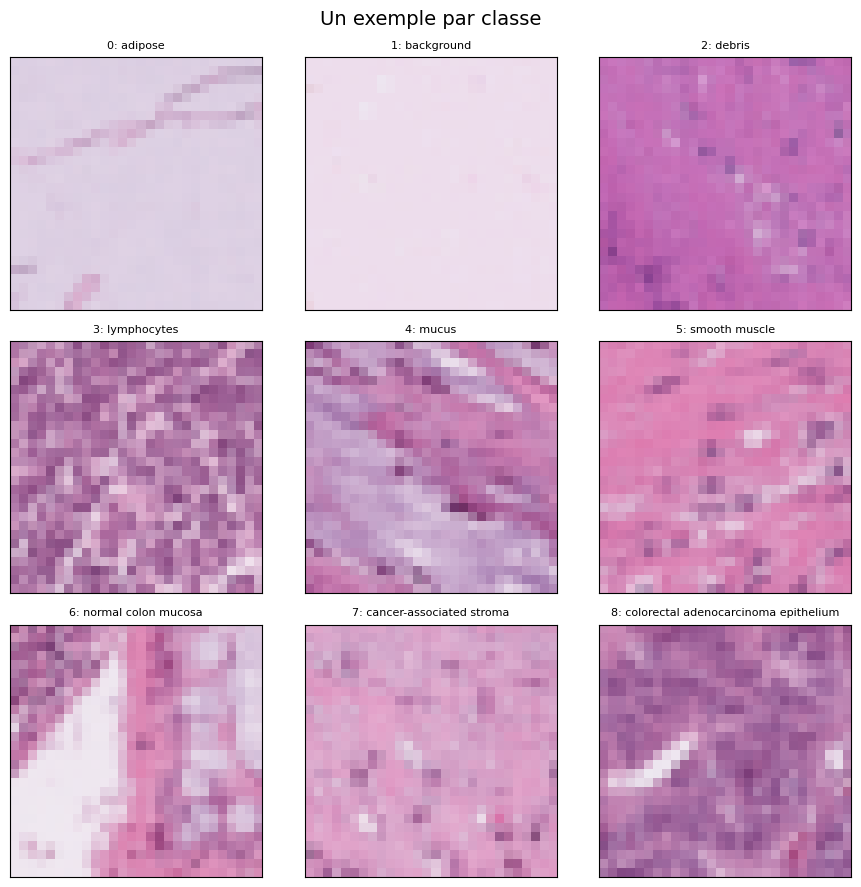

In [11]:
print("=== Visualisation avec un exemple par classe ===")
# Visualisation avec un exemple par classe pour voir à quoi ressemblent les 9 types de tissus
fig, axes = plt.subplots(3, 3, figsize=(9, 9))
for classe in range(9):
    # np.where trouve tous les index de cette classe, [0][0] prend le premier
    idx = np.where(labels == classe)[0][0]
    row, col = divmod(classe, 3)
    axes[row, col].imshow(imgs[idx])
    axes[row, col].set_title(f"{classe}: {labels_names[str(classe)]}", fontsize=8)
    axes[row, col].set_xticks([]); axes[row, col].set_yticks([])

plt.suptitle("Un exemple par classe", fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'graphs', 'NB1_exemples_par_classe.png'), dpi=120, bbox_inches='tight')
plt.show()

=== Visualisation : 5 exemples par classe ===


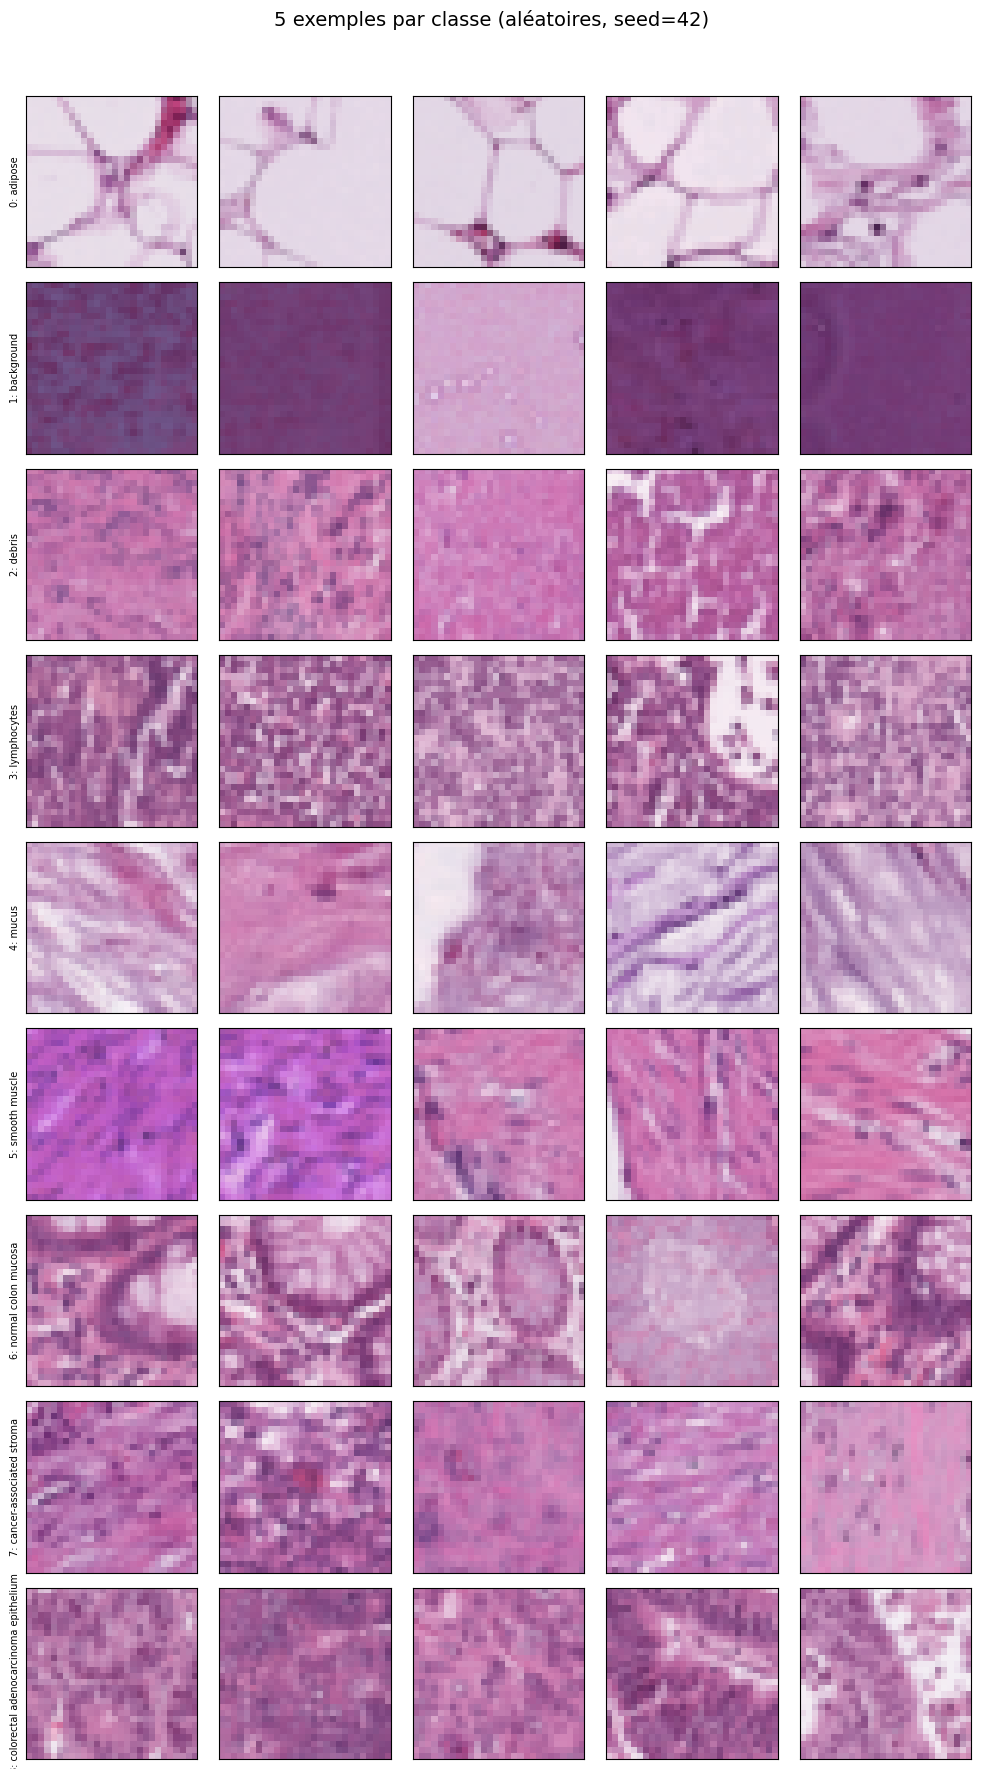

In [12]:
print("=== Visualisation : 5 exemples par classe ===")
# Visualisation : 5 exemples par classe pour observer la variabilité intra-classe
# Si les images d'une même classe sont très différentes entre elles (forte variabilité),
# le modèle aura plus de mal à apprendre cette classe
np.random.seed(SEED)
fig, axes = plt.subplots(9, 5, figsize=(10, 18))
for classe in range(9):
    all_idxs = np.where(labels == classe)[0]
    idxs = np.random.choice(all_idxs, size=5, replace=False)
    for j, idx in enumerate(idxs):
        axes[classe, j].imshow(imgs[idx])
        axes[classe, j].set_xticks([]); axes[classe, j].set_yticks([])
        if j == 0:
            axes[classe, j].set_ylabel(f"{classe}: {labels_names[str(classe)]}", fontsize=7)

plt.suptitle("5 exemples par classe (aléatoires, seed=42)", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])  # laisser de la place pour le titre
plt.savefig(os.path.join(DATA_DIR, 'graphs', 'NB1_5_exemples_par_classe.png'), dpi=120, bbox_inches='tight')
plt.show()

---

### Observations visuelles par classe

- **Adipose (classe 0)** : images blanches, très claires, peu de variation entre elles. Tissu graisseux peu dense : classe facile à identifier
- **Background (classe 1)** : la classe la plus variable : certaines images sont violacées, d'autres gris clair. Risque de confusion avec d'autres classes foncées
- **Debris (classe 2)** : mélange hétérogène de fragments clairs et foncés, pas de structure nette. Ressemble au background : paire à surveiller
- **Lymphocytes (classe 3)** : petites cellules foncées et denses. Cellules immunitaires : leur présence signale une réaction inflammatoire ou tumorale
- **Mucus (classe 4)** : zones claires avec des tons rosés caractéristiques
- **Smooth muscle (classe 5)** : fibres parallèles, tons roses soutenus — structure régulière et orientée
- **Normal colon mucosa (classe 6)** : tissu épithélial organisé, structures glandulaires visibles
- **Cancer-associated stroma (classe 7)** : tissu conjonctif rose pâle, fibres désorganisées : visuellement proche du smooth muscle
- **Tumor epithelium (classe 8)** : images foncées et violettes. La coloration H&E se fixe sur les noyaux cellulaires, les tissus cancéreux en ont beaucoup (multiplication anormale). Certaines images pourraient ressembler à du stroma ou de la muqueuse

Les classes les plus variables (background, debris, smooth muscle, epithelium) sont celles où les images d'une même classe ne se ressemblent pas entre elles. C'est là que le modèle aura le plus de mal.

À 28×28 pixels, les images sont très pixélisées. La distinction entre certaines paires (Debris/Background, Stroma/Smooth muscle) est difficile même pour l'oeil humain. La couleur et la texture seront les deux signaux discriminants principaux.

---

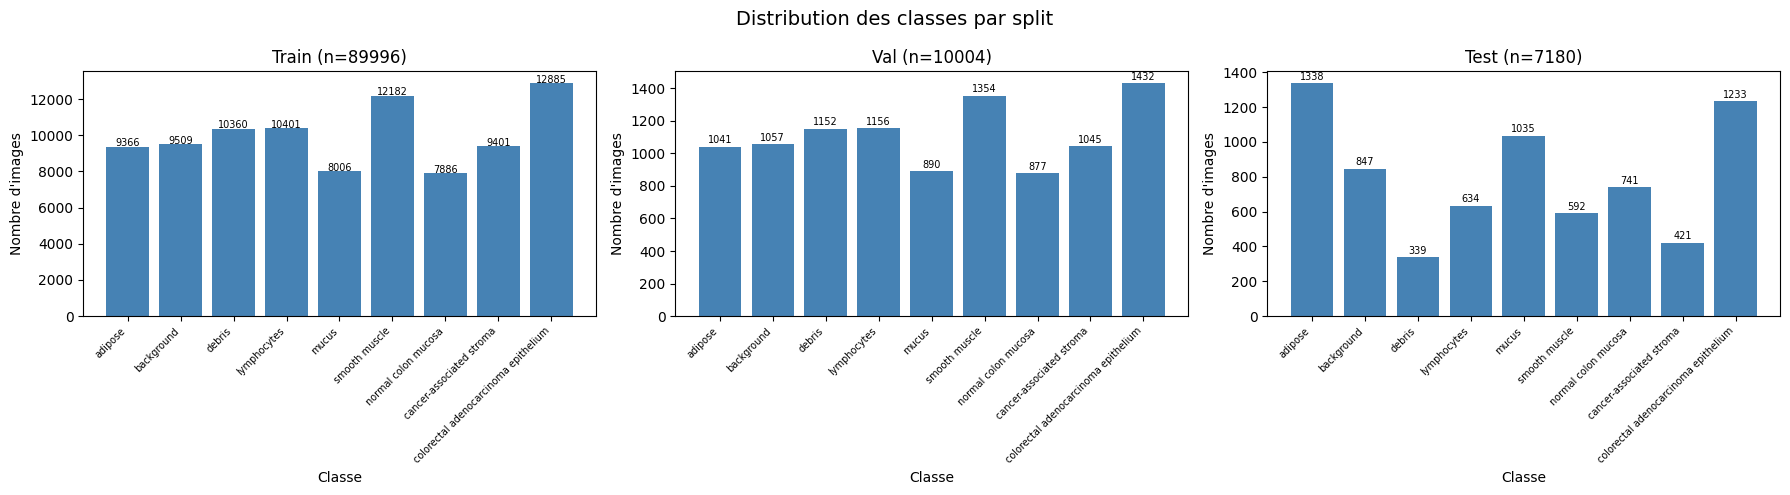

=== Comparaison train vs val vs test (moyennes par classe) ===
Classe                                           Train moy      Val moy     Test moy  Δ train-test   Train nb     Val nb    Test nb
----------------------------------------------------------------------------------------------------------------------------------
0: adipose                                        207.6083     207.5815     216.6987       +9.0904       9366       1041       1338
1: background                                     142.2679     144.0249     112.1767      -30.0912       9509       1057        847
2: debris                                         165.0764     164.7149     164.9995       -0.0768      10360       1152        339
3: lymphocytes                                    156.9267     156.8838     162.7133       +5.7866      10401       1156        634
4: mucus                                          180.9118     181.0467     177.3887       -3.5231       8006        890       1035
5: smooth musc

In [13]:
# Distribution des classes sur les 3 splits, vérifier la cohérence
# Le train et le val viennent du même hôpital (NCT-CRC-HE-100K)
# Le test vient d'un autre hôpital (CRC-VAL-HE-7K)
# Il faut vérifier que les classes sont réparties de manière similaire
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, ds) in zip(axes, [("Train", train_dataset), ("Val", val_dataset), ("Test", test_dataset)]):
    ds_labels = ds.labels.flatten()
    counts = np.bincount(ds_labels, minlength=9)
    bars = ax.bar(range(9), counts, color='steelblue')
    ax.set_xticks(range(9))
    ax.set_xticklabels([labels_names[str(i)] for i in range(9)], rotation=45, ha='right', fontsize=7)
    ax.set_xlabel("Classe")
    ax.set_ylabel("Nombre d'images")
    ax.set_title(f"{name} (n={len(ds)})")
    for bar, count in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20, str(count), ha='center', fontsize=7)

plt.suptitle("Distribution des classes par split", fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'graphs', 'NB1_distribution_classes.png'), dpi=120, bbox_inches='tight')
plt.show()

# Comparaison train vs val vs test — mise en évidence du domain shift
print("=== Comparaison train vs val vs test (moyennes par classe) ===")
print(f"{'Classe':<45s} {'Train moy':>12s} {'Val moy':>12s} {'Test moy':>12s} {'Δ train-test':>13s} {'Train nb':>10s} {'Val nb':>10s} {'Test nb':>10s}")
print("-" * 130)
train_labels = train_dataset.labels.flatten()
val_labels = val_dataset.labels.flatten()
test_labels = test_dataset.labels.flatten()
for c in range(9):
    train_moy = train_dataset.imgs[train_labels == c].mean()
    val_moy = val_dataset.imgs[val_labels == c].mean()
    test_moy = test_dataset.imgs[test_labels == c].mean()
    train_nb = (train_labels == c).sum()
    val_nb = (val_labels == c).sum()
    test_nb = (test_labels == c).sum()
    print(f"{c}: {labels_names[str(c)]:<42s} {train_moy:>12.4f} {val_moy:>12.4f} {test_moy:>12.4f} {test_moy - train_moy:>+13.4f} {train_nb:>10d} {val_nb:>10d} {test_nb:>10d}")

---

### Observation importante : train et test viennent de deux hôpitaux différents

Le dataset est propre et structuré et ne nécessite aucun nettoyage : il n'y a pas de valeurs manquantes, pas de pixels hors plage, pas de labels incorrects : dataset prêt pour la modélisation.

Le train et le val proviennent du même hôpital (NCT-CRC-HE-100K), mais le test vient d'un autre (CRC-VAL-HE-7K). Les statistiques descriptives montrent des différences notables entre les deux, sur les intensités moyennes et le nombre d'images par classe.

- **Background** : moy 142 (train) vs 112 (test), càd plus foncé dans le test
- **Debris** : 10 360 images en train vs 339 en test soit presque 30x moins

Le ratio max/min des classes est d'environ 1.6x dans le train donne un déséquilibre modéré. Cela justifie l'utilisation de l'accuracy comme métrique principale (comme demandé dans le sujet). Toutefois, on surveillera aussi le F1-score par classe pour détecter d'éventuels biais sur les classes minoritaires.

Conséquence : le modèle pourrait bien fonctionner sur le val mais moins bien sur le test. Ce phénomène courant en imagerie médicale s'appelle le domain shift.

---

### Pourquoi le domain shift est pertinent ici

Le test set de PathMNIST provient d'un hôpital différent du train/val, ce qui permet de simuler les conditions réelles de déploiement.

En production, un modèle entraîné dans un hôpital doit fonctionner dans d'autres établissements où les conditions varient : protocole de coloration H&E (concentration des produits, durée d'incubation, alcool utilisé), épaisseur et qualité des coupes, variabilité humaine et microscope utilisé pour l'acquisition. Ces variations modifient l'apparence des images sans changer le diagnostic.

Si train et test venaient du même hôpital, les résultats seraient bons mais ne refléteraient pas la réalité de terrain. L'écart val/test qu'on observera sera un indicateur honnête de ce qu'on aurait en déploiement clinique.

---

=== Boxplots par classe : visualisation de la distribution ===


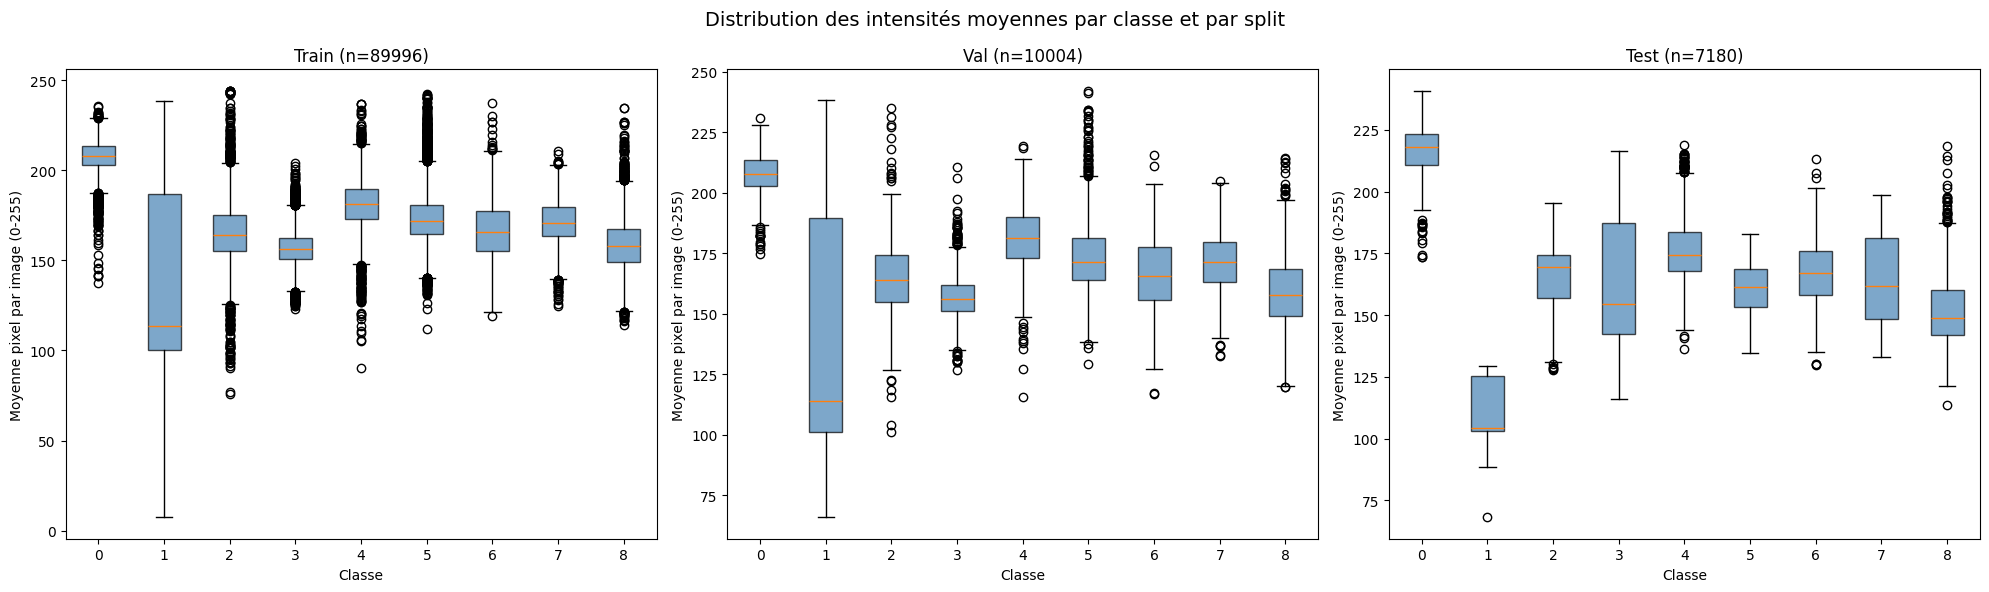

In [14]:
%matplotlib inline
print("=== Boxplots par classe : visualisation de la distribution ===")
# Boxplots par classe : visualisation de la distribution des pixels
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, (split_name, ds) in zip(axes, [("Train", train_dataset), ("Val", val_dataset), ("Test", test_dataset)]):
    ds_imgs = ds.imgs
    ds_labels = ds.labels.flatten()
    # on récupère uniquement (N,) 
    
    # Moyenne des pixels par image (une valeur par image, pas par pixel)
    data = [ds_imgs[ds_labels == c].mean(axis=(1, 2, 3)) for c in range(9)]
    
    bp = ax.boxplot(data, tick_labels=[str(c) for c in range(9)], patch_artist=True)
    for patch in bp['boxes']:
        patch.set_facecolor('steelblue')
        patch.set_alpha(0.7)
    ax.set_xlabel("Classe")
    ax.set_ylabel("Moyenne pixel par image (0-255)")
    ax.set_title(f"{split_name} (n={len(ds)})")

plt.suptitle("Distribution des intensités moyennes par classe et par split", fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'graphs', 'NB1_boxplots.png'), dpi=120, bbox_inches='tight')
plt.show()

---

### Observation sur les boxplots et la distribution par split

Les boxplots révèlent que les distributions sont quasi identiques entre train et val (attendu car ils proviennent du même hôpital (NCT-CRC-HE-100K)), découpé en ratio 90/10.

En revanche, le test (CRC-VAL-HE-7K, hôpital différent) montre des différences :
- Les médianes de certaines classes sont décalées (ex : background plus foncé en test)
- La dispersion (taille des boîtes) varie, certaines classes sont plus homogènes dans un hôpital que dans l'autre
- Les proportions sont différentes : debris très présent en train (10 360 images) mais rare en test (339 images). Peut-être que l'hôpital B prépare peut-être ses lames différemment (et surement plus proprement :) )

Comme expliqué précédement, ce phénomène (domain shift) est courant en imagerie médicale : chaque hôpital a ses propres protocoles et méthodes d'acquisition. Un modèle performant sur un hôpital ne l'est pas forcément sur un autre. C'est pourquoi l'écart val/test sera un indicateur clé dans les parties suivantes.

---

In [15]:
print("=== Statistiques descriptives complètes par classe et par split ===")
# Statistiques descriptives complètes par classe et par split
from scipy import stats as sp_stats

for split_name, ds in [("TRAIN", train_dataset), ("VAL", val_dataset), ("TEST", test_dataset)]:
    ds_imgs = ds.imgs
    ds_labels = ds.labels.flatten()
    ds_labels_names = ds.info['label']
    
    print(f"\n=== {split_name} (n={len(ds)}) ===")
    print(f"{'Classe':<45s} {'Nb':>6s} {'Moy':>10s} {'Std':>10s} {'Min':>5s} {'Q1':>8s} {'Med':>8s} {'Q3':>8s} {'Max':>5s} {'IQR':>8s} {'Skew':>8s} {'Kurt':>8s}")
    print("-" * 140)
    for c in range(9):
        pixels = ds_imgs[ds_labels == c].flatten()
        q1 = np.percentile(pixels, 25)
        q3 = np.percentile(pixels, 75)
        print(f"{c}: {ds_labels_names[str(c)]:<42s} {(ds_labels == c).sum():>6d} {pixels.mean():>10.4f} {pixels.std():>10.4f} {pixels.min():>5d} {q1:>8.4f} {np.median(pixels):>8.4f} {q3:>8.4f} {pixels.max():>5d} {q3-q1:>8.4f} {sp_stats.skew(pixels):>8.4f} {sp_stats.kurtosis(pixels):>8.4f}")

=== Statistiques descriptives complètes par classe et par split ===

=== TRAIN (n=89996) ===
Classe                                            Nb        Moy        Std   Min       Q1      Med       Q3   Max      IQR     Skew     Kurt
--------------------------------------------------------------------------------------------------------------------------------------------
0: adipose                                      9366   207.6083    25.5257     0 200.0000 215.0000 223.0000   252  23.0000  -2.1761   6.6903
1: background                                   9509   142.2679    56.8725     0 111.0000 130.0000 191.0000   255  80.0000   0.2682  -0.9893
2: debris                                      10360   165.0764    40.3549     0 136.0000 172.0000 195.0000   255  59.0000  -0.4556  -0.2883
3: lymphocytes                                 10401   156.9267    35.9225    27 135.0000 159.0000 181.0000   252  46.0000  -0.2470  -0.2710
4: mucus                                        8006   180.91

---

### Comment sont calculées les statistiques descriptives sur des images ?

Chaque image est composée de pixels (nombres entre 0 et 255). Pour calculer les stats d'une classe, on prend toutes les images de cette classe et on met tous leurs pixels dans une seule liste :

- 1 image = 28 × 28 × 3 = 2 352 valeurs
- Classe adipose (10 407 images) = 10 407 × 2 352 = ~24 millions de valeurs

Sur cette liste, on calcule les stats classiques : moyenne, écart-type, min, max, quartiles (Q1, médiane, Q3), IQR, skewness et kurtosis. C'est l'équivalent d'un `describe()` en données tabulaires, appliqué aux pixels.

- **Moyenne élevée** (ex : adipose 207) = classe claire
- **Moyenne basse** (ex : cancer 157) = classe foncée
- **Écart-type élevé** (ex : background 56) = forte variabilité intra-classe, risque de confusion
- **Skewness négative** = distribution décalée vers les valeurs hautes (images claires)
- **Kurtosis élevé** = pics marqués dans la distribution (pixels concentrés autour de quelques valeurs)

---

=== Corrélation entre canaux RGB ===


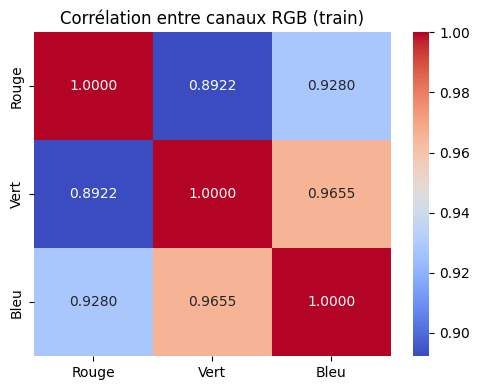

In [16]:
print("=== Corrélation entre canaux RGB ===")
# Corrélation entre canaux RGB — est-ce que les canaux portent de l'info différente ?
# Si deux canaux sont très corrélés, l'un des deux est "redondant"
pixels_flat = imgs.reshape(-1, 3)  # (N*28*28, 3) — tous les pixels du train
corr_matrix = np.corrcoef(pixels_flat.T)  # matrice 3×3

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(corr_matrix, annot=True, fmt='.4f', cmap='coolwarm',
            xticklabels=['Rouge', 'Vert', 'Bleu'], yticklabels=['Rouge', 'Vert', 'Bleu'], ax=ax)
ax.set_title('Corrélation entre canaux RGB (train)')
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'graphs', 'NB1_correlation_rgb.png'), dpi=120, bbox_inches='tight')
plt.show()

---

### Interprétation de la corrélation RGB

Les 3 canaux sont fortement corrélés (R-V : 0.89, R-B : 0.93), càd que quand un pixel est clair, il l'est sur les 3 canaux, et inversement. C'est logique car c'est une caractéristique des colorations HE : les images vont du blanc (adipose, tout élevé) au violet foncé (cancer, tout bas).

Cependant, le canal vert est le moins corrélé avec les deux autres, ce qui est aussi cohérent : le violet (caractéristique de la coloration H&E) c'est du rouge + bleu **sans** vert. Le vert est donc le canal qui apporte l'information la plus différenciante entre les classes.

Conséquence : malgré la forte corrélation, on ne convertit pas en niveaux de gris car le vert porte une info complémentaire essentielle. Et on normalise canal par canal, pas globalement.

---

=== Distribution des intensités moyennes par classe ===


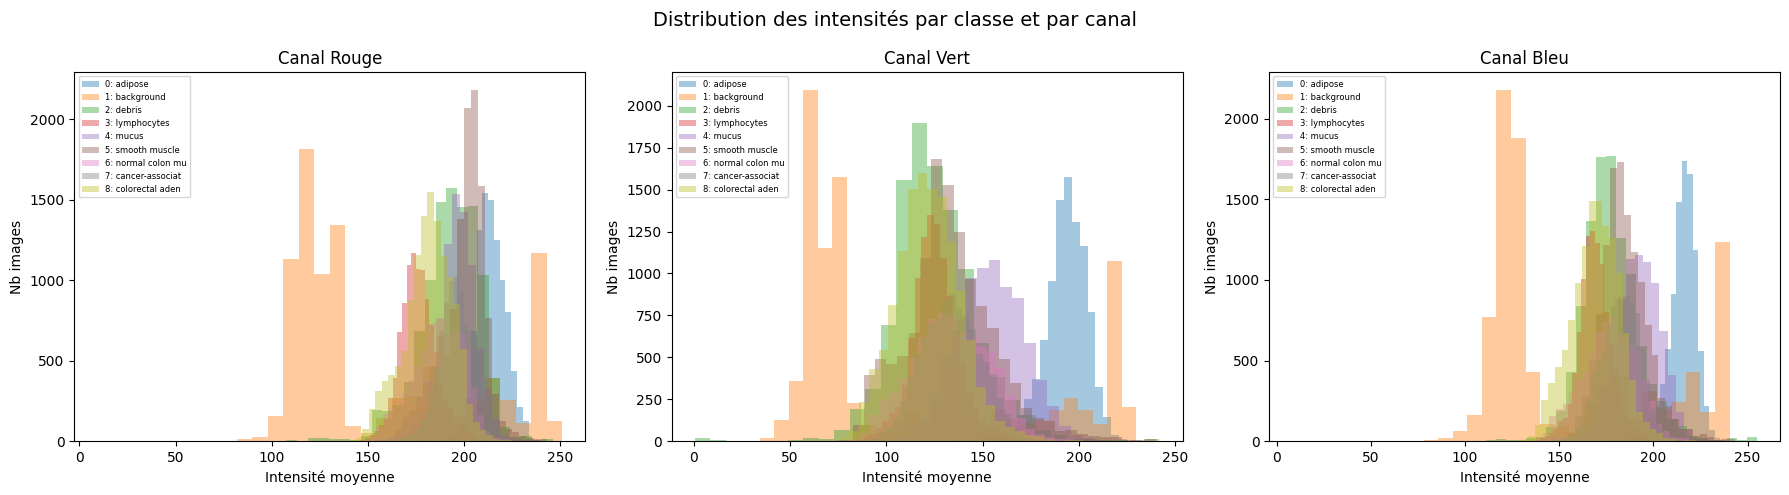

In [17]:
print("=== Distribution des intensités moyennes par classe ===")
# Distribution des intensités moyennes par classe (superposées)
# Permet de voir quelles classes se chevauchent (confusions potentielles)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ch, (ax, canal) in enumerate(zip(axes, ['Rouge', 'Vert', 'Bleu'])):
    for c in range(9):
        mask = labels == c
        pixel_means = imgs[mask, :, :, ch].mean(axis=(1, 2))  # moyenne par image
        ax.hist(pixel_means, bins=30, alpha=0.4, label=f'{c}: {labels_names[str(c)][:15]}')
    ax.set_xlabel('Intensité moyenne')
    ax.set_ylabel('Nb images')
    ax.set_title(f'Canal {canal}')
    ax.legend(fontsize=6)

plt.suptitle('Distribution des intensités par classe et par canal', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'graphs', 'NB1_distribution_intensites.png'), dpi=120, bbox_inches='tight')
plt.show()

---

### Analyse de la distribution des intensités par classe et par canal

**Canal Rouge :**
- L'adipose (bleu clair) est isolée à droite (~200-220) et sera de ce fait très facile à distinguer
- Les autres classes se chevauchent fortement entre 100 et 180
- Le background (orange) est très étalé, ce qui confirme sa forte variabilité

**Canal Vert, le plus discriminant :**
- C'est le canal qui sépare le mieux les classes : l'adipose est à droite (~180), le cancer et les lymphocytes sont à gauche (~80-100)
- Le chevauchement est moins important que sur le rouge et le bleu
- Confirme la corrélation RGB : le vert porte l'info la plus différenciante

**Canal Bleu :**
- Profil similaire au rouge, fort chevauchement entre les classes
- L'adipose se détache à droite, comme sur les deux autres canaux

**Observations clés :**
- **Adipose** est facile à classifier sur les 3 canaux, décalée vers la droite (claire)
- **Lymphocytes, cancer, stroma** se chevauchent au centre, c'est là que des confusions risquent de se produire
- **Background** a la distribution la plus étalée : cohérent avec son écart-type élevé
- Le **canal vert** sera le plus utile au modèle pour séparer les classes foncées entre elles

---

=== Q1.1 Comparing Background vs Debris ===


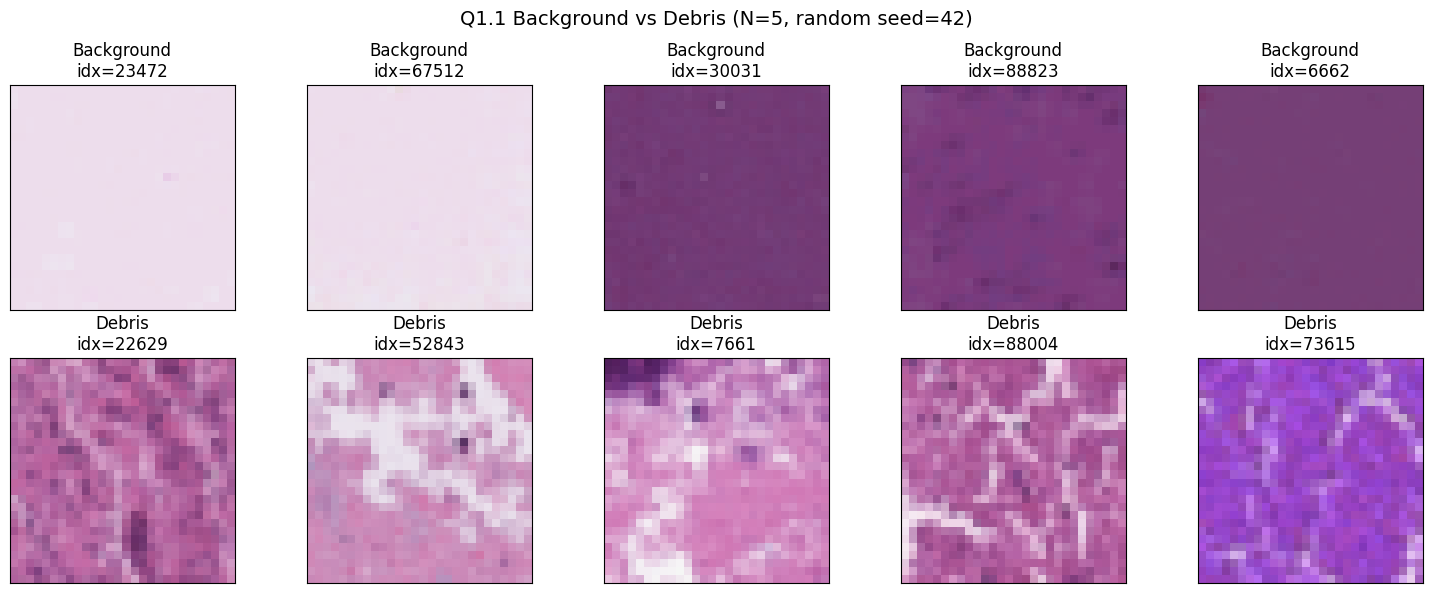

Sampled Background indices: [23472 67512 30031 88823  6662]
Sampled Debris indices    : [22629 52843  7661 88004 73615]


In [18]:
print("=== Q1.1 Comparing Background vs Debris ===")
# Q1.1 Comparing Background vs Debris (random seeded sampling)
# Q1.1 Look at several images from the Debris class and several from Background.
# Describe in your own words what visual differences you observe between them.

np.random.seed(SEED)

BACKGROUND_LABEL = 1
DEBRIS_LABEL = 2
N = 5

# --- Safety checks (Lab style) ---
unique_labels = np.unique(labels)
assert BACKGROUND_LABEL in unique_labels, "Background label not found in dataset"
assert DEBRIS_LABEL in unique_labels, "Debris label not found in dataset"
assert imgs.ndim == 4 and imgs.shape[-1] == 3, f"Expected imgs as (N,H,W,3), got {imgs.shape}"

# Indices par classe
idx_background = np.where(labels == BACKGROUND_LABEL)[0]
idx_debris = np.where(labels == DEBRIS_LABEL)[0]

assert len(idx_background) >= N, f"Not enough Background samples: {len(idx_background)}"
assert len(idx_debris) >= N, f"Not enough Debris samples: {len(idx_debris)}"

# Tirage aléatoire reproductible
sample_background = np.random.choice(idx_background, size=N, replace=False)
sample_debris = np.random.choice(idx_debris, size=N, replace=False)

# Plot: 2 lignes x N colonnes
fig, axes = plt.subplots(2, N, figsize=(3*N, 6))

for j, idx in enumerate(sample_background):
    axes[0, j].imshow(imgs[idx])
    axes[0, j].set_title(f"Background\nidx={idx}")
    axes[0, j].set_xticks([]); axes[0, j].set_yticks([])

for j, idx in enumerate(sample_debris):
    axes[1, j].imshow(imgs[idx])
    axes[1, j].set_title(f"Debris\nidx={idx}")
    axes[1, j].set_xticks([]); axes[1, j].set_yticks([])

plt.suptitle(f"Q1.1 Background vs Debris (N={N}, random seed={SEED})", fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'graphs', 'NB1_q11_debris_vs_background.png'), dpi=120, bbox_inches='tight')
plt.show()

# Vérification : les labels correspondent bien
assert np.all(labels[sample_background] == BACKGROUND_LABEL)
assert np.all(labels[sample_debris] == DEBRIS_LABEL)

print("Sampled Background indices:", sample_background)
print("Sampled Debris indices    :", sample_debris)

---

**Q1.1 : Debris vs Background :**

Sur 5 échantillons seedés :
- **Background (classe 1)** : la texture est uniforme, avec peu de structures visibles, l'intensité est plus ou moins homogène sur l'ensemble de l'image.
- **Debris (classe 2)** : la texture est hétérogène, avec des fragments de tailles et d'intensités variées, le contraste est plus marqué entre les zones claires et les zones foncées. Il y a des petites zones granulaires très foncées qui donnent un aspect fragmenté. Cependant, certaines images semblent atypiques de débrits. La dernière image notamment, avec sa coloration bleu/violette, détonne du reste et ne ressemble pas particulièrement à des débrits. 
- **Couleur** : les débris tirent vers des tons roses/violets plus marqués que le tissu background, qui est soit quasiment blanc, soit violet plus foncé.

La différence principale entre les deux classes est la texture : homogène pour le background, granuleuse pour les débris.

---

=== Q1.2 : Comparaison visuelle : PathMNIST vs ImageNet synthétique ===
Image sélectionnée : index #15795 du TRAIN, classe 1 (background)


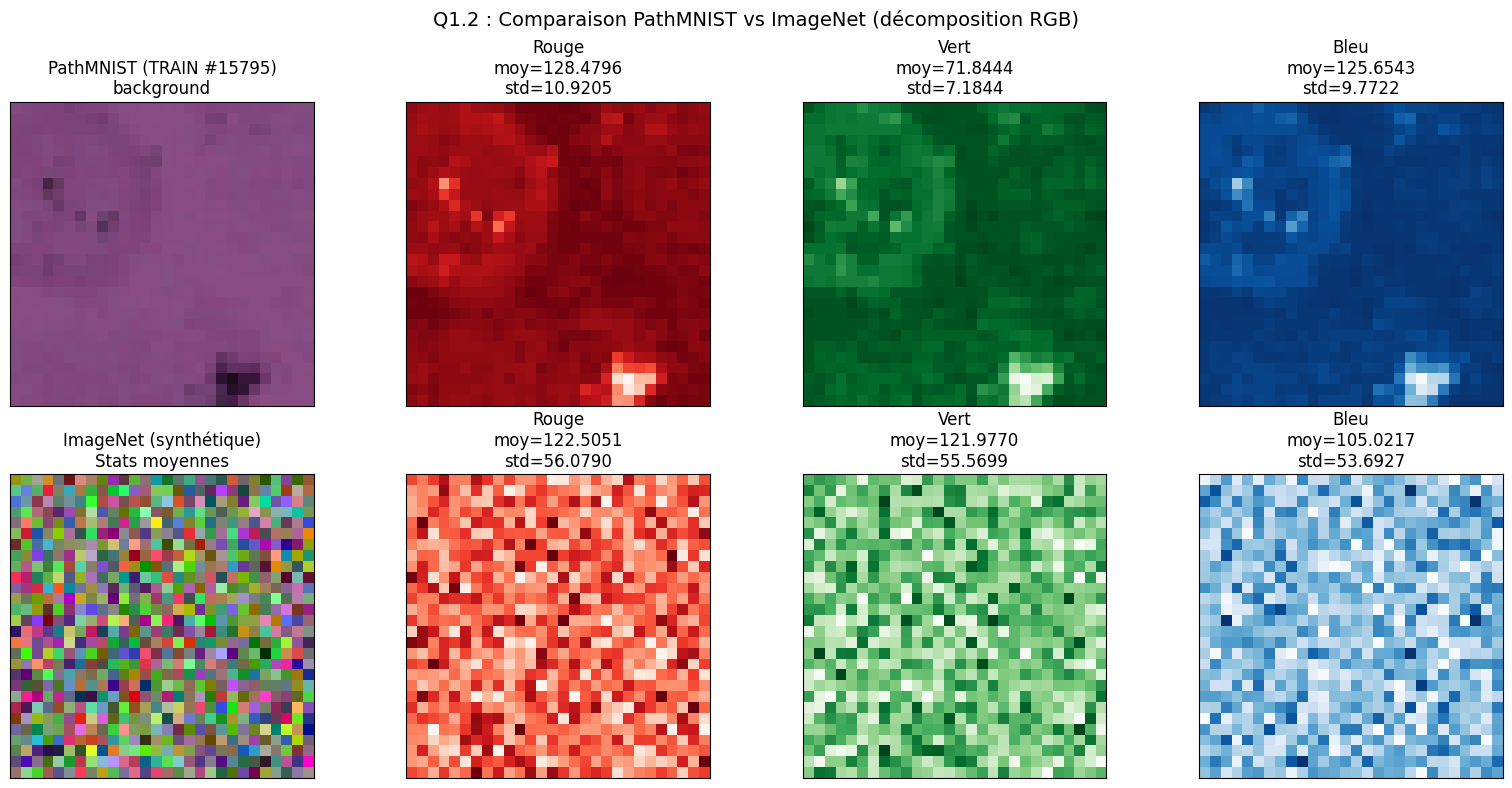


=== Pixel intensity statistics : PathMNIST vs ImageNet ===
Canal      Path moy   Path std   ImgN moy   ImgN std
--------------------------------------------------
Rouge      128.4796    10.9205   123.6750    58.3950
Vert        71.8444     7.1844   116.2800    57.1200
Bleu       125.6543     9.7722   103.5300    57.3750


In [19]:
print("=== Q1.2 : Comparaison visuelle : PathMNIST vs ImageNet synthétique ===")
# Q1.2 : Comparaison visuelle : image PathMNIST vs image type ImageNet
# On montre la décomposition RGB de notre image + une image synthétique
# créée avec les stats moyennes d'ImageNet pour illustrer la différence

np.random.seed(SEED)
idx_q12 = np.random.randint(0, len(train_dataset))
img_q12 = imgs[idx_q12]
print(f"Image sélectionnée : index #{idx_q12} du TRAIN, classe {labels[idx_q12]} ({labels_names[str(labels[idx_q12])]})")

# Image synthétique "type ImageNet" : pixels générés à partir des stats moyennes
# Juste pour illustrer la différence de profil colorimétrique
imagenet_mean_255 = np.array([0.485, 0.456, 0.406]) * 255
imagenet_std_255 = np.array([0.229, 0.224, 0.225]) * 255
np.random.seed(SEED)
img_imagenet = np.stack([
    np.clip(np.random.normal(imagenet_mean_255[i], imagenet_std_255[i], (28, 28)), 0, 255).astype(np.uint8)
    for i in range(3)
], axis=-1)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

# Ligne 1 : notre image PathMNIST
axes[0, 0].imshow(img_q12)
axes[0, 0].set_title(f"PathMNIST (TRAIN #{idx_q12})\n{labels_names[str(labels[idx_q12])]}")
for i, (canal, cmap) in enumerate(zip(["Rouge", "Vert", "Bleu"], ["Reds", "Greens", "Blues"])):
    axes[0, i+1].imshow(img_q12[:, :, i], cmap=cmap)
    axes[0, i+1].set_title(f"{canal}\nmoy={img_q12[:,:,i].mean():.4f}\nstd={img_q12[:,:,i].std():.4f}")

# Ligne 2 : image type ImageNet (synthétique)
axes[1, 0].imshow(img_imagenet)
axes[1, 0].set_title("ImageNet (synthétique)\nStats moyennes")
for i, (canal, cmap) in enumerate(zip(["Rouge", "Vert", "Bleu"], ["Reds", "Greens", "Blues"])):
    axes[1, i+1].imshow(img_imagenet[:, :, i], cmap=cmap)
    axes[1, i+1].set_title(f"{canal}\nmoy={img_imagenet[:,:,i].mean():.4f}\nstd={img_imagenet[:,:,i].std():.4f}")

for ax in axes.flat:
    ax.set_xticks([]); ax.set_yticks([])

plt.suptitle("Q1.2 : Comparaison PathMNIST vs ImageNet (décomposition RGB)", fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'graphs', 'NB1_q12_pathmnist_vs_imagenet.png'), dpi=120, bbox_inches='tight')
plt.show()

# Tableau comparatif
print("\n=== Pixel intensity statistics : PathMNIST vs ImageNet ===")
print(f"{'Canal':<8s} {'Path moy':>10s} {'Path std':>10s} {'ImgN moy':>10s} {'ImgN std':>10s}")
print("-" * 50)
for i, c in enumerate(["Rouge", "Vert", "Bleu"]):
    print(f"{c:<8s} {img_q12[:,:,i].mean():>10.4f} {img_q12[:,:,i].std():>10.4f} {imagenet_mean_255[i]:>10.4f} {imagenet_std_255[i]:>10.4f}")

---

**Q1.2 Réponse :**

On sélectionne une image au hasard dans le train (seed=42, comme demandé : "pick any single image"). L'image tirée est l'index #15795, classe smooth muscle. On compare en échelle [0, 255] car l'image brute est en uint8 (format standard des images : 0 = noir, 255 = blanc, les stats ImageNet sont multipliées par 255 pour être sur la même échelle).

Les statistiques par canal RGB de cette image vs ImageNet :

| Canal | PathMNIST #15795 moy | PathMNIST #15795 std | ImageNet moy | ImageNet std |
|-------|---------------------------|---------------|-------------|-------------|
| Rouge | 128.4796 | 10.9205| 123.6750 | 58.3950 |
| Vert | 71.8444 | 7.1844 | 116.2800 | 57.1200 |
| Bleu | 125.6543 | 9.7722 | 103.5300 | 57.3750 |

Les écarts sont nets : notre image a des valeurs rouge et bleu plus élevées et un vert plus bas que ImageNet. Ce profil violet/rose est caractéristique de la coloration H&E en histopathologie, très différent des photos naturelles d'ImageNet. Ces résultats ne sont pas du tout inattendus. 

Conclusion : on ne peut pas utiliser les stats ImageNet telles quelles pour la normalisation. On utilisera les stats calculées sur notre propre train set pour les modèles from scratch, et on testera la normalisation ImageNet pour le transfer learning (partie 4).

Ces écarts justifient d'utiliser nos propres statistiques (NORM_MEAN, NORM_STD) plutôt que celles d'ImageNet pour la normalisation des modèles from scratch.

---

---

### BONUS POUR ANALYSE

---

=== BONUS — Comparaison globale PathMNIST vs ImageNet ===


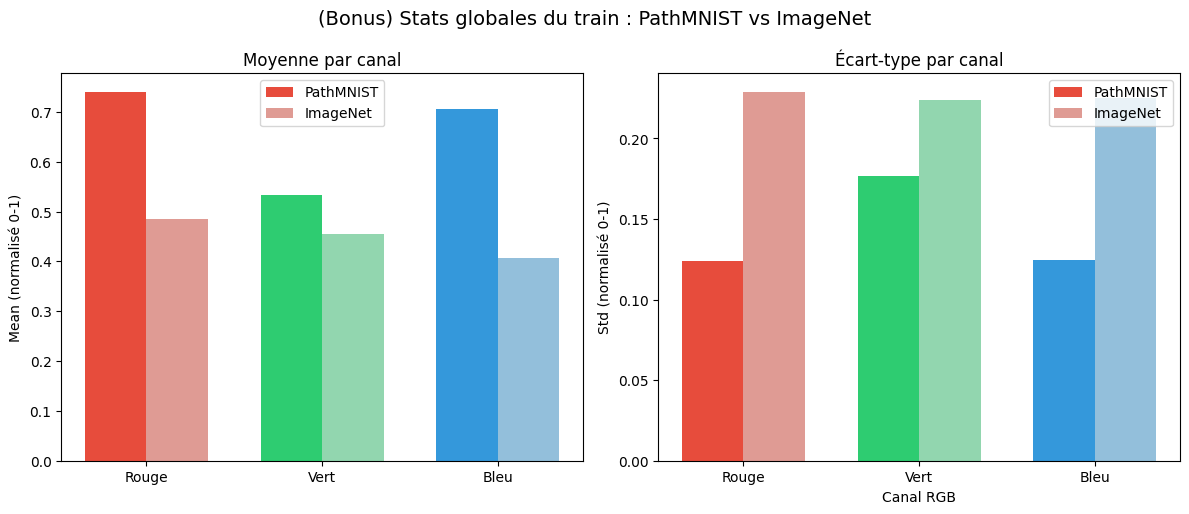


=== Écarts PathMNIST vs ImageNet ===
Canal     Path moy  ImgN moy     Δ moy  Path std  ImgN std     Δ std
--------------------------------------------------------------
Rouge       0.7405    0.4850   +0.2555    0.1237    0.2290   -0.1053
Vert        0.5330    0.4560   +0.0770    0.1768    0.2240   -0.0472
Bleu        0.7058    0.4060   +0.2998    0.1244    0.2250   -0.1006


In [20]:
print("=== BONUS — Comparaison globale PathMNIST vs ImageNet ===")
# BONUS — Comparaison globale PathMNIST vs ImageNet
# Stats calculées sur TOUT le dataset train (89 996 images),
# pas sur une seule image, plus fiable pour décider de la normalisation

# On divise par 255 pour passer de [0-255] à [0-1],
# car les stats ImageNet sont exprimées en [0-1]
path_mean = imgs.mean(axis=(0, 1, 2)) / 255.0
path_std = imgs.std(axis=(0, 1, 2)) / 255.0

# Stats ImageNet — référence pour le transfer learning
imagenet_mean = np.array([0.485, 0.456, 0.406])
imagenet_std = np.array([0.229, 0.224, 0.225])

x = np.arange(3)
canaux = ["Rouge", "Vert", "Bleu"]
width = 0.35

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.bar(x - width/2, path_mean, width, label='PathMNIST', color=['#e74c3c', '#2ecc71', '#3498db'])
ax1.bar(x + width/2, imagenet_mean, width, label='ImageNet', color=['#c0392b', '#27ae60', '#2980b9'], alpha=0.5)
ax1.set_xticks(x); ax1.set_xticklabels(canaux)
ax1.set_ylabel("Mean (normalisé 0-1)")
ax1.set_title("Moyenne par canal")
ax1.legend()

ax2.bar(x - width/2, path_std, width, label='PathMNIST', color=['#e74c3c', '#2ecc71', '#3498db'])
ax2.bar(x + width/2, imagenet_std, width, label='ImageNet', color=['#c0392b', '#27ae60', '#2980b9'], alpha=0.5)
ax2.set_xticks(x); ax2.set_xticklabels(canaux)
ax2.set_ylabel("Std (normalisé 0-1)")
ax2.set_title("Écart-type par canal")
ax2.legend()

plt.suptitle("(Bonus) Stats globales du train : PathMNIST vs ImageNet", fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'graphs', 'NB1_bonus_global_vs_imagenet.png'), dpi=120, bbox_inches='tight')
plt.xlabel('Canal RGB')
plt.show()

# Écarts absolus
print("\n=== Écarts PathMNIST vs ImageNet ===")
print(f"{'Canal':<8s} {'Path moy':>9s} {'ImgN moy':>9s} {'Δ moy':>9s} {'Path std':>9s} {'ImgN std':>9s} {'Δ std':>9s}")
print("-" * 62)
for i, c in enumerate(["Rouge", "Vert", "Bleu"]):
    print(f"{c:<8s} {path_mean[i]:>9.4f} {imagenet_mean[i]:>9.4f} {path_mean[i]-imagenet_mean[i]:>+9.4f} {path_std[i]:>9.4f} {imagenet_std[i]:>9.4f} {path_std[i]-imagenet_std[i]:>+9.4f}")

---

### Écarts PathMNIST vs ImageNet

Les écarts confirment que nos images d'histologie sont très différentes des photos naturelles :

- **Rouge et Bleu** : Δ > +0.25, nos images sont beaucoup plus rouges/bleues qu'ImageNet (coloration H&E)
- **Vert** : Δ = +0.08, écart plus faible, mais le vert reste plus élevé dans nos images (composante claire de l'éosine)
- **Écart-type** : nos images ont un écart-type plus faible qu'ImageNet sur les 3 canaux, les couleurs H&E sont plus homogènes que dans des photos naturelles (moins de variété de scènes)

---

=== BONUS — Barres mean/std ===


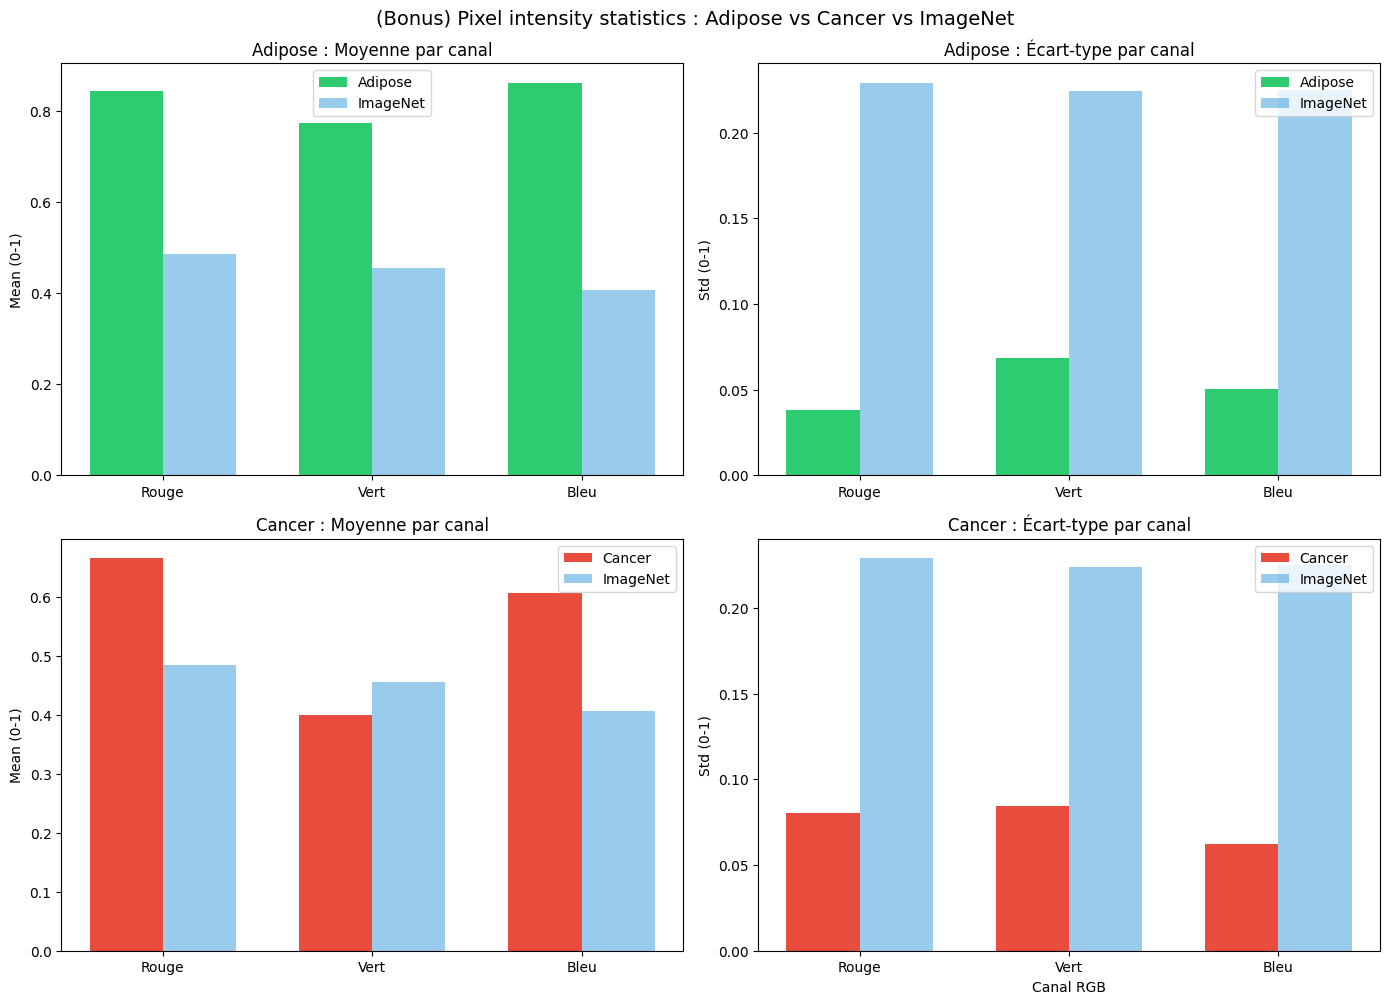

In [21]:
print("=== BONUS — Barres mean/std ===")
# BONUS — Barres mean/std : image saine au-dessus, image cancer en dessous
np.random.seed(SEED)
idx_sain = np.random.choice(np.where(labels == 0)[0])
idx_cancer = np.random.choice(np.where(labels == 8)[0])
img_sain = imgs[idx_sain]
img_cancer = imgs[idx_cancer]

img_sain_mean = [img_sain[:,:,i].mean() / 255.0 for i in range(3)]
img_sain_std = [img_sain[:,:,i].std() / 255.0 for i in range(3)]
img_cancer_mean = [img_cancer[:,:,i].mean() / 255.0 for i in range(3)]
img_cancer_std = [img_cancer[:,:,i].std() / 255.0 for i in range(3)]

x = np.arange(3)
canaux = ["Rouge", "Vert", "Bleu"]
width = 0.35

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Ligne 1 : Adipose (sain)
axes[0, 0].bar(x - width/2, img_sain_mean, width, label='Adipose', color='#2ecc71')
axes[0, 0].bar(x + width/2, imagenet_mean, width, label='ImageNet', color='#3498db', alpha=0.5)
axes[0, 0].set_xticks(x); axes[0, 0].set_xticklabels(canaux)
axes[0, 0].set_ylabel("Mean (0-1)"); axes[0, 0].set_title("Adipose : Moyenne par canal"); axes[0, 0].legend()

axes[0, 1].bar(x - width/2, img_sain_std, width, label='Adipose', color='#2ecc71')
axes[0, 1].bar(x + width/2, imagenet_std, width, label='ImageNet', color='#3498db', alpha=0.5)
axes[0, 1].set_xticks(x); axes[0, 1].set_xticklabels(canaux)
axes[0, 1].set_ylabel("Std (0-1)"); axes[0, 1].set_title("Adipose : Écart-type par canal"); axes[0, 1].legend()

# Ligne 2 : Cancer
axes[1, 0].bar(x - width/2, img_cancer_mean, width, label='Cancer', color='#e74c3c')
axes[1, 0].bar(x + width/2, imagenet_mean, width, label='ImageNet', color='#3498db', alpha=0.5)
axes[1, 0].set_xticks(x); axes[1, 0].set_xticklabels(canaux)
axes[1, 0].set_ylabel("Mean (0-1)"); axes[1, 0].set_title("Cancer : Moyenne par canal"); axes[1, 0].legend()

axes[1, 1].bar(x - width/2, img_cancer_std, width, label='Cancer', color='#e74c3c')
axes[1, 1].bar(x + width/2, imagenet_std, width, label='ImageNet', color='#3498db', alpha=0.5)
axes[1, 1].set_xticks(x); axes[1, 1].set_xticklabels(canaux)
axes[1, 1].set_ylabel("Std (0-1)"); axes[1, 1].set_title("Cancer : Écart-type par canal"); axes[1, 1].legend()

plt.suptitle("(Bonus) Pixel intensity statistics : Adipose vs Cancer vs ImageNet", fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'graphs', 'NB1_bonus_sain_vs_cancer_vs_imagenet.png'), dpi=120, bbox_inches='tight')
plt.xlabel('Canal RGB')
plt.show()

---

### Analyse des pixel intensity statistics : Adipose vs Cancer vs ImageNet

**Moyenne (mean) :**
- L'adipose a des moyennes élevées et proches sur les 3 canaux (~0.80) : image claire, proche du blanc
- Le cancer a un profil déséquilibré : rouge et bleu élevés, vert nettement plus bas, c'est le violet H&E
- ImageNet est plus bas et plus équilibré (~0.45-0.49) : profil typique de photos naturelles

**Écart-type (std) :**
- L'adipose a un écart-type très faible : image homogène, peu de variation
- Le cancer a un écart-type plus élevé : plus de variation intra-image (zones denses vs zones claires)
- ImageNet a les écarts-types les plus élevés : les photos naturelles ont beaucoup plus de diversité de couleurs qu'une lame H&E

Ces graphiques confirment visuellement que les stats PathMNIST et ImageNet sont incompatibles pour la normalisation.

---

=== BONUS : Comparaison unitaire : tissu sain vs tissu malade ===


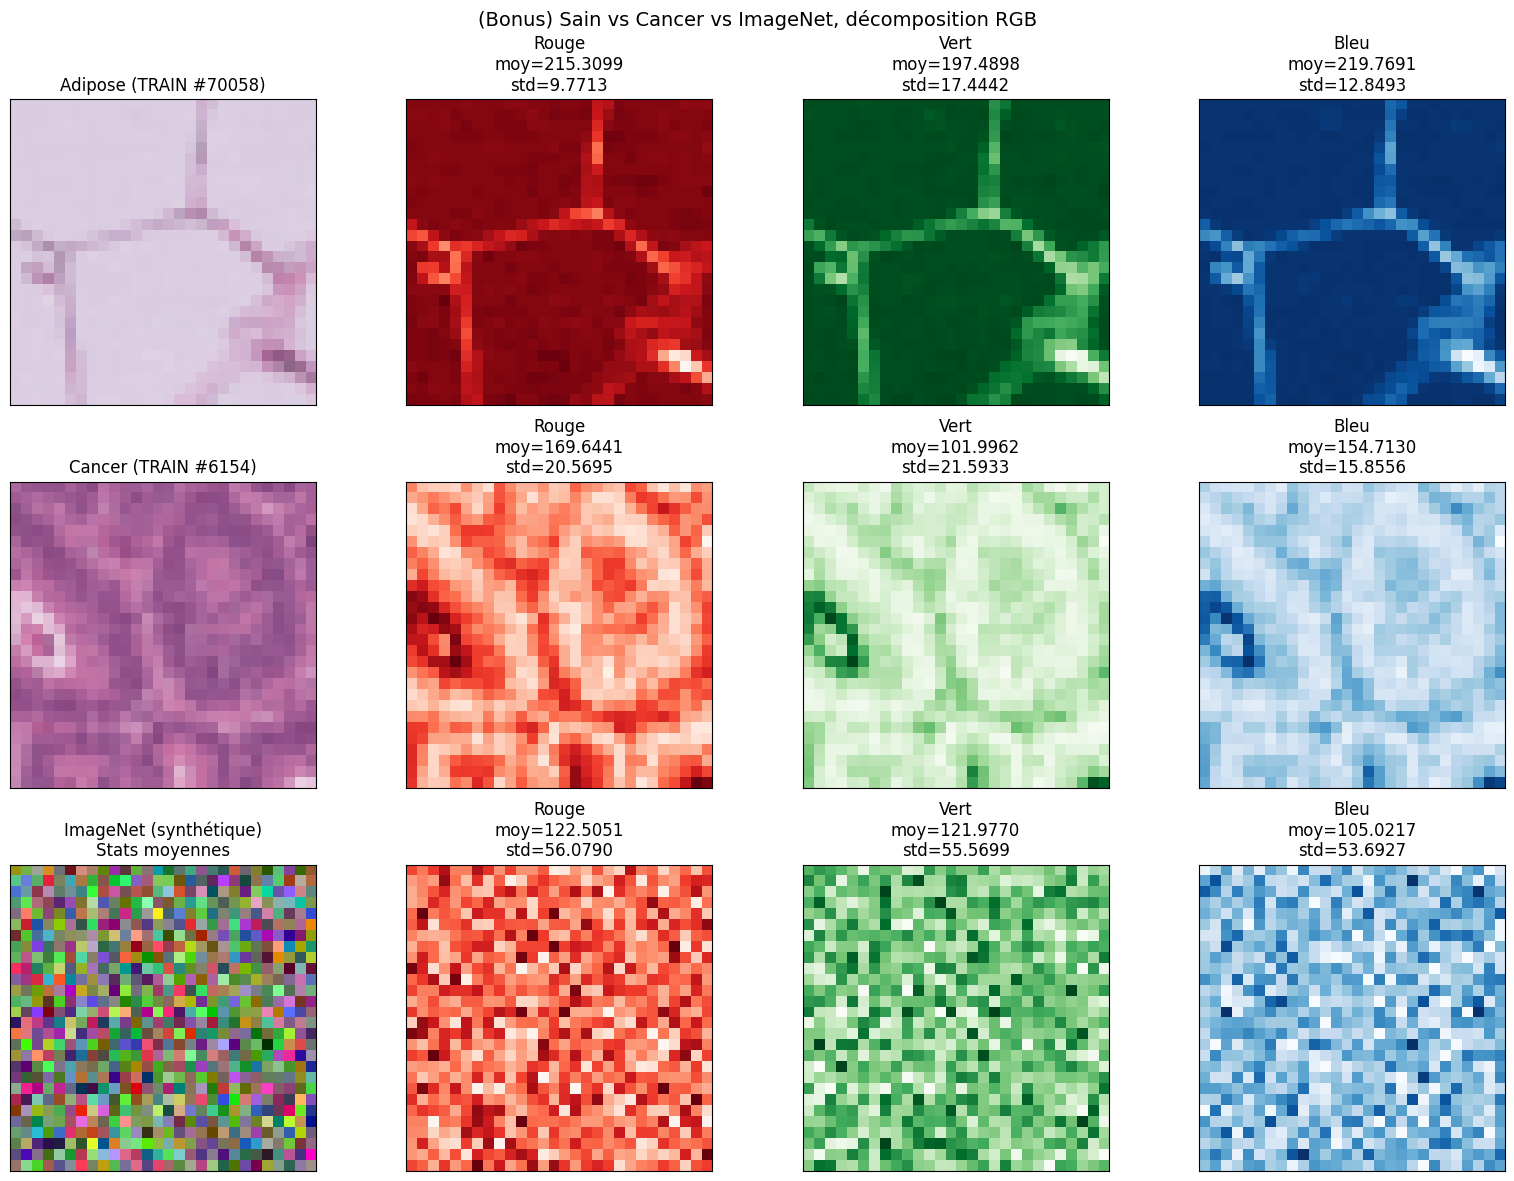

In [22]:
print("=== BONUS : Comparaison unitaire : tissu sain vs tissu malade ===")
# BONUS : Comparaison unitaire : tissu sain vs tissu malade vs ImageNet
# Permet de voir comment le profil RGB varie selon le type de tissu
np.random.seed(SEED)
idx_sain = np.random.choice(np.where(labels == 0)[0])
idx_cancer = np.random.choice(np.where(labels == 8)[0])
img_sain = imgs[idx_sain]
img_cancer = imgs[idx_cancer]

# Image synthétique ImageNet (générée à partir des stats moyennes)
imagenet_mean_255 = np.array([0.485, 0.456, 0.406]) * 255
imagenet_std_255 = np.array([0.229, 0.224, 0.225]) * 255
np.random.seed(SEED)
img_imagenet = np.stack([
    np.clip(np.random.normal(imagenet_mean_255[i], imagenet_std_255[i], (28, 28)), 0, 255).astype(np.uint8)
    for i in range(3)
], axis=-1)

fig, axes = plt.subplots(3, 4, figsize=(16, 12))

# Ligne 1 : Adipose (sain)
axes[0, 0].imshow(img_sain)
axes[0, 0].set_title(f"Adipose (TRAIN #{idx_sain})")
for i, (canal, cmap) in enumerate(zip(["Rouge", "Vert", "Bleu"], ["Reds", "Greens", "Blues"])):
    axes[0, i+1].imshow(img_sain[:, :, i], cmap=cmap)
    axes[0, i+1].set_title(f"{canal}\nmoy={img_sain[:,:,i].mean():.4f}\nstd={img_sain[:,:,i].std():.4f}")

# Ligne 2 : Cancer
axes[1, 0].imshow(img_cancer)
axes[1, 0].set_title(f"Cancer (TRAIN #{idx_cancer})")
for i, (canal, cmap) in enumerate(zip(["Rouge", "Vert", "Bleu"], ["Reds", "Greens", "Blues"])):
    axes[1, i+1].imshow(img_cancer[:, :, i], cmap=cmap)
    axes[1, i+1].set_title(f"{canal}\nmoy={img_cancer[:,:,i].mean():.4f}\nstd={img_cancer[:,:,i].std():.4f}")

# Ligne 3 : ImageNet synthétique
axes[2, 0].imshow(img_imagenet)
axes[2, 0].set_title("ImageNet (synthétique)\nStats moyennes")
for i, (canal, cmap) in enumerate(zip(["Rouge", "Vert", "Bleu"], ["Reds", "Greens", "Blues"])):
    axes[2, i+1].imshow(img_imagenet[:, :, i], cmap=cmap)
    axes[2, i+1].set_title(f"{canal}\nmoy={img_imagenet[:,:,i].mean():.4f}\nstd={img_imagenet[:,:,i].std():.4f}")

for ax in axes.flat:
    ax.set_xticks([]); ax.set_yticks([])

plt.suptitle("(Bonus) Sain vs Cancer vs ImageNet, décomposition RGB", fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'graphs', 'NB1_bonus_sain_vs_cancer_vs_imagenet.png'), dpi=120, bbox_inches='tight')
plt.show()

---

### (Bonus) Comparaison sain vs cancer vs ImageNet :

L'image adipose (sain) tire vers le blanc : les 3 canaux ont des moyennes élevées et proches (blanc = R + G + B élevés). L'image cancer tire vers le violet : rouge et bleu forts, vert nettement plus bas (violet = R + B sans G). L'image ImageNet (synthétique) montre un profil beaucoup plus équilibré entre les 3 canaux, avec des moyennes plus basses (~104-124), typique de photos naturelles.

Cette comparaison visuelle confirme que PathMNIST et ImageNet ont des distributions de couleur très différentes. La coloration H&E (violet/rose) de nos images n'a rien à voir avec les photos de chiens et de voitures d'ImageNet. C'est pourquoi on utilisera nos propres stats de normalisation pour les modèles from scratch, et on réservera les stats ImageNet pour le transfer learning (partie 4). Le full fine-tuning surpasse largement le frozen backbone, et illustrent bien le domain shift entre PathMNIST et ImageNet. Les filtres préentraînées sur ImageNet vont devoir s'adapter pour être efficaces sur des images médicales.

---

=== BONUS Histogrammes de distribution des pixels ===


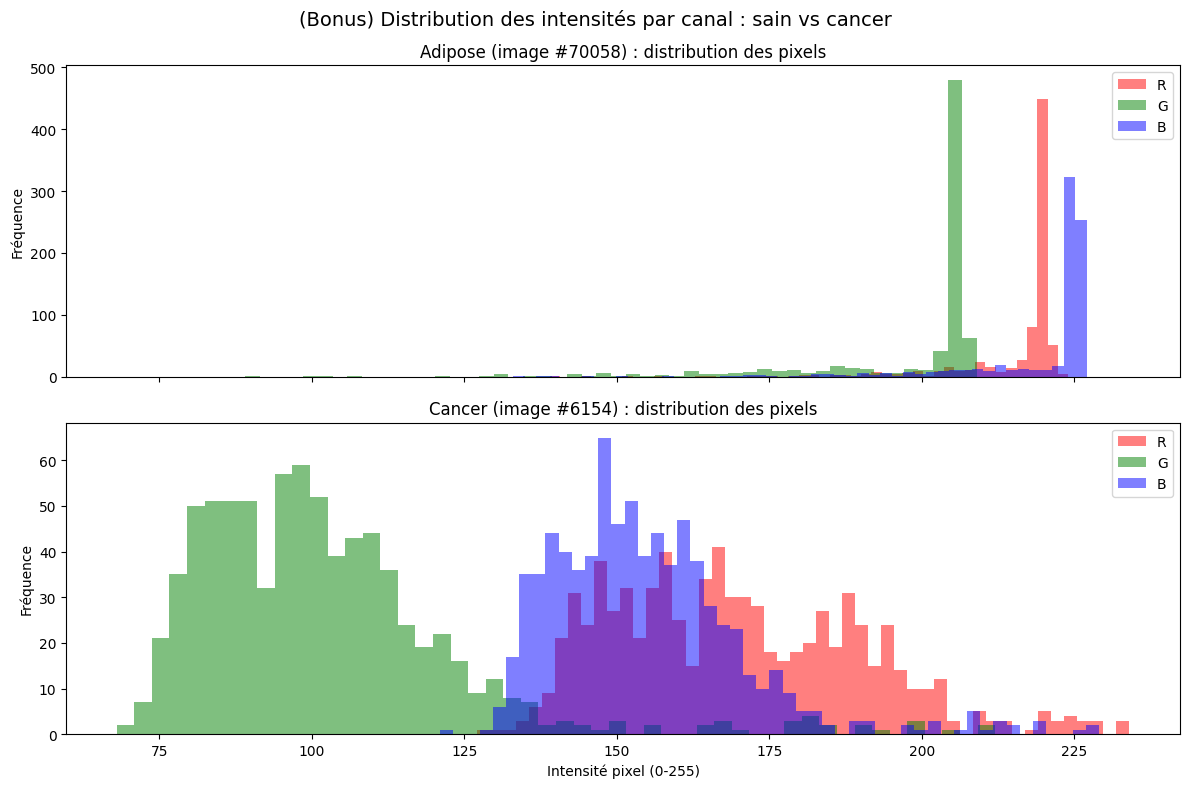

In [23]:
print("=== BONUS Histogrammes de distribution des pixels ===")
# BONUS Histogrammes de distribution des pixels : Adipose (sain) vs Cancer
# Appuie l'hypothèse : le cancer a plus de pixels foncés (noyaux denses)
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Adipose
for i, (color, label) in enumerate(zip(["red", "green", "blue"], ["R", "G", "B"])):
    axes[0].hist(img_sain[:,:,i].flatten(), bins=50, alpha=0.5, color=color, label=label)
axes[0].set_title(f"Adipose (image #{idx_sain}) : distribution des pixels")
axes[0].set_ylabel("Fréquence")
axes[0].legend()

# Cancer
for i, (color, label) in enumerate(zip(["red", "green", "blue"], ["R", "G", "B"])):
    axes[1].hist(img_cancer[:,:,i].flatten(), bins=50, alpha=0.5, color=color, label=label)
axes[1].set_title(f"Cancer (image #{idx_cancer}) : distribution des pixels")
axes[1].set_xlabel("Intensité pixel (0-255)")
axes[1].set_ylabel("Fréquence")
axes[1].legend()

plt.suptitle("(Bonus) Distribution des intensités par canal : sain vs cancer", fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'graphs', 'NB1_distribution_intensites.png'), dpi=120, bbox_inches='tight')
plt.show()

---

### Ce que les histogrammes de distribution des pixels nous apprennent

- **Adipose (sain)** : les 3 couleurs (R, G, B) sont regroupées dans les valeurs hautes et se superposent, c'est logique, l'image est presque blanche.
- **Cancer** : le rouge et le bleu restent hauts, mais le vert chute nettement. Les 3 couleurs ne se superposent plus, c'est ce qui donne la teinte violette.

Cette comparaison permet de montrer certaines facilités de classification, car Adipose vs Cancer sont deux extrêmes visuels. Cependant, la véritable difficulté du dataset va résider dans ders paires similaires, notamment la différence entre les classes Cancer Epithelium vs Normal Mucosa, qui présentent des statistiques de pixels proches.

---


=== BONUS Histogrammes de distribution des pixels ===


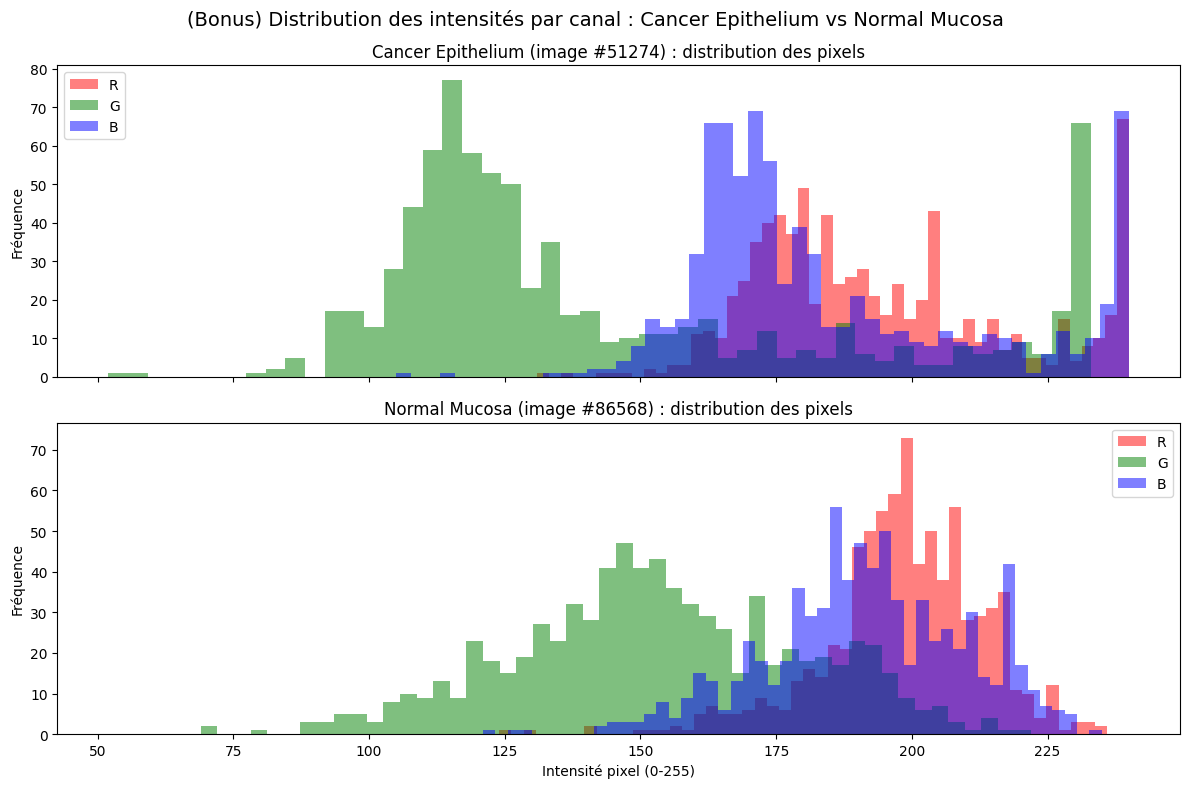

In [24]:
print("=== BONUS Histogrammes de distribution des pixels ===")
# BONUS Histogrammes de distribution des pixels : Cancer Epithelium vs Normal Mucosa
# Ces deux classes sont cliniquement opposées mais visuellement similaires
# C'est là que réside la vraie difficulté du dataset

np.random.seed(SEED)
idx_cancer = np.random.choice(np.where(labels == 8)[0])  # Cancer Epithelium
idx_mucosa = np.random.choice(np.where(labels == 6)[0])  # Normal Mucosa

img_cancer = imgs[idx_cancer]
img_mucosa = imgs[idx_mucosa]

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Cancer Epithelium
for i, (color, label) in enumerate(zip(["red", "green", "blue"], ["R", "G", "B"])):
    axes[0].hist(img_cancer[:,:,i].flatten(), bins=50, alpha=0.5, color=color, label=label)
axes[0].set_title(f"Cancer Epithelium (image #{idx_cancer}) : distribution des pixels")
axes[0].set_ylabel("Fréquence")
axes[0].legend()

# Normal Mucosa
for i, (color, label) in enumerate(zip(["red", "green", "blue"], ["R", "G", "B"])):
    axes[1].hist(img_mucosa[:,:,i].flatten(), bins=50, alpha=0.5, color=color, label=label)
axes[1].set_title(f"Normal Mucosa (image #{idx_mucosa}) : distribution des pixels")
axes[1].set_xlabel("Intensité pixel (0-255)")
axes[1].set_ylabel("Fréquence")
axes[1].legend()

plt.suptitle("(Bonus) Distribution des intensités par canal : Cancer Epithelium vs Normal Mucosa",
             fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'graphs', 'NB1_distribution_intensites.png'), dpi=120, bbox_inches='tight')
plt.show()

In [25]:
print("=== Calcul des stats de normalisation via DataLoader ===")
# Calcul des stats de normalisation via DataLoader (méthode robuste)
# Fonctionne même sur de très gros datasets : charge les images batch par batch
raw_transform = transforms.Compose([transforms.ToTensor()])
train_raw = PathMNIST(split='train', transform=raw_transform, download=False, root=DATA_DIR)
loader_stats = DataLoader(train_raw, batch_size=512, shuffle=False)

channel_sum = torch.zeros(3)
channel_sq_sum = torch.zeros(3)
n_pixels = 0

for imgs_batch, _ in loader_stats:
    channel_sum += imgs_batch.sum(dim=(0, 2, 3))
    channel_sq_sum += (imgs_batch ** 2).sum(dim=(0, 2, 3))
    n_pixels += imgs_batch.shape[0] * imgs_batch.shape[2] * imgs_batch.shape[3]

NORM_MEAN = (channel_sum / n_pixels).tolist()
NORM_STD = ((channel_sq_sum / n_pixels - (channel_sum / n_pixels) ** 2).sqrt()).tolist()

print(f"NORM_MEAN : {[round(m, 4) for m in NORM_MEAN]}")
print(f"NORM_STD  : {[round(s, 4) for s in NORM_STD]}")
print("✓ Stats de normalisation calculées via DataLoader")

=== Calcul des stats de normalisation via DataLoader ===
NORM_MEAN : [0.7405, 0.533, 0.7058]
NORM_STD  : [0.1237, 0.1768, 0.1244]
✓ Stats de normalisation calculées via DataLoader


---

## Pourquoi normaliser les données ?

Les pixels bruts vont de 0 à 255. Si on les donne tels quels au modèle, les calculs internes produisent des nombres trop grands et l'entraînement devient instable.

La normalisation se fait en deux étapes :
1. On ramène les pixels entre 0 et 1 (division par 255)
2. On centre autour de 0 en soustrayant la moyenne et en divisant par l'écart-type, pour chaque couleur (R, G, B) séparément

**Pourquoi couleur par couleur ?** Nos images H&E ont beaucoup de rouge et de bleu (violet) mais peu de vert. Si on normalisait globalement, ce déséquilibre serait ignoré.

**Pourquoi calculer uniquement sur le train ?** Si on utilisait les données du val ou du test pour calculer la moyenne, le modèle aurait accès à des informations qu'il n'est pas censé connaître avant l'évaluation (data leakage).

---

---

## Décisions figées : Contrat pour la modélisation (parties 2 à 7)

### Périmètre
- **Dataset** : PathMNIST uniquement avec 107 180 images histologiques colorectales
- **Tâche** : classification multi-classe (9 types de tissus)
- **Résolution** : 28×28 pixels RGB (images originales 224×224 réduites par MedMNIST)
- **Conséquence** : résolution très basse pour de l'histologie, les structures cellulaires fines sont perdues, le modèle devra s'appuyer sur les couleurs et textures globales plutôt que sur les détails morphologiques

### Reproductibilité
| Paramètre | Valeur | Conséquence |
|-----------|--------|-------------|
| **Seed** | 42 (torch + numpy) | Résultats identiques à chaque exécution : poids initiaux, shuffle des batches, opérations aléatoires fixés |

### Splits
| Split | N images | Source | Conséquence |
|-------|----------|--------|-------------|
| **Train** | 89 996 | NCT-CRC-HE-100K (hôpital A) | Le modèle apprend uniquement sur ces données |
| **Val** | 10 004 | NCT-CRC-HE-100K (hôpital A, ratio 9:1) | Même distribution que train, ce qui permet de détecter l'overfitting pendant l'entraînement |
| **Test** | 7 180 | CRC-VAL-HE-7K (hôpital B) | Hôpital différent : domain shift possible, test plus exigeant, les performances pourraient être inférieures à celles du val |
| **Split custom** | Non | Splits officiels MedMNIST | Comparabilité directe avec la littérature scientifique |

### Normalisation
| Paramètre | Valeur | Justification |
|-----------|--------|---------------|
| **NORM_MEAN** | [0.7405, 0.5330, 0.7058] | Moyenne par canal R, G, B calculée sur les 89 996 images train uniquement |
| **NORM_STD** | [0.1237, 0.1768, 0.1244] | Écart-type par canal R, G, B calculé sur train uniquement |
| **Calculé sur train uniquement** | Oui | Utiliser val ou test introduirait du data leakage, le modèle aurait accès à des informations futures |
| **ImageNet mean/std** | [0.485, 0.456, 0.406] / [0.229, 0.224, 0.225] | Référence pour le transfer learning (ResNet-18) |
| **Écart PathMNIST vs ImageNet** | Δ mean > 0.25 sur R et B | Les distributions sont très différentes : images médicales H&E ≠ photos naturelles |

**Conséquence sur le choix de normalisation :**
- Modèles from scratch (MLP, CNN, ViT) → stats PathMNIST obligatoires, car le modèle n'a aucun a priori sur les données
- Transfer learning (ResNet-18) → tester les deux. Le modèle a appris des features sur ImageNet avec ses propres stats, mais nos données sont très différentes. Le fine-tuning pourrait compenser l'écart, ou pas, il faut tester

### Équilibre des classes
| Fait | Conséquence |
|------|-------------|
| Ratio max/min ≈ 1.6x (train) | Déséquilibre modéré : pas de classe fortement sous-représentée, pas d'action corrective nécessaire (pas de oversampling, pas de class weights) |
| Distribution test ≠ distribution train | Le test vient d'un autre hôpital, certaines classes ont des proportions différentes (ex: debris 339 en test vs 10 360 en train). Les performances par classe pourraient varier |
| Background test très différent | Moy 112.2 en test vs 142.3 en train — les backgrounds de l'hôpital B sont plus foncés. Source potentielle d'erreurs |

### Hypothèse testable issue de l'EDA
Les classes visuellement proches (Debris/Background : mêmes tons violacés, absence de structure cellulaire nette) et les classes à forte variabilité intra-classe (background std=56.9, epithelium std=41.1) produiront davantage de confusions que les classes visuellement distinctes (Adipose : tissu blanc, moy=207.6, std=25.5). Validation par les matrices de confusion des parties 2 à 5.

### Format d'entrée par modèle
| Modèle | Entrée attendue | Transformation nécessaire |
|--------|----------------|--------------------------|
| MLP (partie 2) | Vecteur 1D de 2352 valeurs | Flatten 28×28×3 → 2352 |
| CNN (partie 3) | Tensor 3D de 3×28×28 | ToTensor() uniquement |
| ResNet-18 (partie 4) | Tensor 3D de 3×224×224 | Resize 28→224 (upscaling 8×) |
| ViT (partie 5) | Patches de l'image | Patch embedding (taille à définir) |

---



In [26]:
print("=== Sanity check — vérifier les stats ===")
# Sanity check — vérifier que les stats sont bien en [0, 1] et pas en [0, 255]
assert all(m < 1.0 for m in NORM_MEAN), "NORM_MEAN doit être en [0,1], pas en [0,255] !"
assert all(s < 1.0 for s in NORM_STD), "NORM_STD doit être en [0,1], pas en [0,255] !"
print("✓ Sanity check : NORM_MEAN et NORM_STD sont bien en [0, 1]")

=== Sanity check — vérifier les stats ===
✓ Sanity check : NORM_MEAN et NORM_STD sont bien en [0, 1]


In [27]:
print("=== Temps total d'exécution du notebook ===")
# Temps total d'exécution du notebook
notebook_total_time = time.time() - notebook_start_time
print(f"Temps total du notebook : {notebook_total_time:.1f}s ({notebook_total_time/60:.1f} min)")

=== Temps total d'exécution du notebook ===
Temps total du notebook : 38.1s (0.6 min)
